In [44]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
from sklearn import metrics
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'

In [45]:
# LIB: Base

task = "Task"
shovel = "Shovel"
cube = "Cube"

condition_key = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]
condition_labels = ["Controller\nNone", "Controller\nSubtle", "Controller\nPronounced", "Proxy\nNone", "Proxy\nSubtle", "Proxy\nPronounced"]

#colors = ['tab:green', 'tab:orange', 'tab:red', 'tab:blue', 'tab:purple', 'tab:brown']
#colors = ["#FFD600", "#FF6D00", "#D50000", "#2962FF", "#AA00FF", "#C51162"]
colors = ["#00C853", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]
#colors = ['tab:green', 'tab:yellow', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:red']
#colors = ["#4CAF50", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]

device_key = "Device"
device_proxy = "P"
device_controller = "C"
devices = [device_controller, device_proxy]
device_labels = ["Controller", "Proxy"]

scaling_key = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"
scalings = [scaling_none, scaling_subtle, scaling_pronounced]
scaling_labels = ["None", "Subtle", "Pronounced"]

device_x_scaling_key = "Device * Scaling"

subject_key = "Subject"

def get_confidence_interval(values):
    return 1.96 * stats.sem(values)

In [46]:
# LIB: Measurements

cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    "24_JoHi",
    #LS5
    "25_LeSc",
    "26_BaBa",
    "27_KaHi",
    "28_JoSc",
    "29_JeHo",
    "30_LiPa",
    #LS6
    "31_GiDe",
    "32_AnRa",
    "33_MaSu",
    "34_MiDo",
    "35_FlRu",
    "36_FaAs",
    #LS7
    "37_SiMi",
    "38_FaUe",
    "39_JeOb",
    "40_HeSe",
    "41_AnOb",
    "42_StSp",
    ]

hmd = "hmd"

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_res_key = 'GSR Resistance CAL'
gsr_con_key = 'GSR Conductance CAL'
imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_res_key, gsr_con_key]

baseline_ms = 30_000

def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df, e):
    return df[unity_unix_key].min()
    # if e == cube:
    #     return df[unity_unix_key].min()
    # else:
    #     first_load = df[(df["collision_or_load_count"] == 1)]
    #     return first_load[unity_unix_key].min()

def task_end(df, e):
    return df[unity_unix_key].max()
    # if e == cube:
    #     return df[unity_unix_key].max()
    # else:
    #     final_load = df[(df["collision_or_load_count"] == 20)]
    #     final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

    #     return final_unload[unity_unix_key].min()
    
def trim_df(df, min_ts, max_ts):
    min_trimmed = df[(df[unified_unix_key] >= min_ts)]
    full_trimmed = min_trimmed[(min_trimmed[unified_unix_key] <= max_ts)]
    return full_trimmed

def calc_pt_deltas(unity_df, pt):
    unity_df[pt + "_x_delta"] = unity_df[pt + "_x"].diff()
    unity_df[pt + "_y_delta"] = unity_df[pt + "_y"].diff()
    unity_df[pt + "_z_delta"] = unity_df[pt + "_z"].diff()

    new_df = unity_df.dropna(subset = [pt + "_x_delta", pt + "_y_delta", pt + "_z_delta"])

    new_df[pt+"_delta_dist"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_y_delta"], x[pt + "_z_delta"]), (0,0,0)), axis = 1)
    new_df[pt+"_delta_dist_planar"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_z_delta"]), (0,0)), axis = 1)
    new_df[pt+"_delta_dist_vertical"] = new_df.apply(lambda x: abs(x[pt + "_y_delta"]), axis = 1) #TODO check if this makes sense

    return new_df

def get_pt_path_len(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist"].sum()

def get_pt_path_len_planar(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_planar"].sum()

def get_pt_path_len_vertical(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_vertical"].sum()

def sync_timestamps(unity_df, imot_df, e):
    task_start_ts = task_start(unity_df, e)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c, augment_unity):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw, e)
    unity_synced = synced[0]
    imot_synced = synced[1]

    # Add HMD path data
    if augment_unity:
        unity_synced = calc_pt_deltas(unity_synced, hmd)

    task_start_ts = task_start(unity_raw, e)
    task_end_ts = task_end(unity_raw, e)

    #imot_pre_task = trim_df(imot_synced, task_start_ts - baseline_ms, task_start_ts)
    #min_hr = imot_pre_task.dropna(subset = hr_key)[hr_key].quantile(extrema_quantile)
    #min_gsr_con = imot_pre_task.dropna(subset = gsr_con_key)[gsr_con_key].quantile(extrema_quantile)

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts,
        #"min_hr": min_hr,
        #"min_gsr_con": min_gsr_con
    }

def get_experiment(p, e, augment_unity):
    condition_data = list(map(lambda x: get_condition(p, e, x, augment_unity), conditions))

    #min_hr = np.min(list(map(lambda x: x["min_hr"], condition_data)))
    #min_gsr_con = np.min(list(map(lambda x: x["min_gsr_con"], condition_data)))

    return {
            c_0: condition_data[0],
            c_1: condition_data[1],
            c_2: condition_data[2],
            p_0: condition_data[3],
            p_1: condition_data[4],
            p_2: condition_data[5],
            #"min_hr": min_hr,
            #"min_gsr_con": min_gsr_con
    }
def get_participant(p, augment_unity):
    return {
        cube: get_experiment(p, cube, augment_unity),
        shovel: get_experiment(p, shovel, augment_unity),
        subject_key: p
    }

In [47]:
# LIB: Significance Testing

significance_key = "Significance"
aov_key = "aov"
pairwise_key = "pairwise"
eff_size_key = "ng2"

def get_significant_entries(df):
    return df[df[significance_key] == "✅"]

def get_semi_significant_entries(df):
    return df[df[significance_key] != "❌"]

def rm_anova(df, value_key, two_way):
    within = [device_key, scaling_key] if two_way else condition_key

    aov = pg.rm_anova(
        dv=value_key,
        within=within,
        subject=subject_key,
        data=df,
        detailed=True
    )

    p_unc = "p-unc"
    p_corr = "p-GG-corr"
    aov[significance_key] = aov.apply(lambda x:
        "✅" if
            (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if p_corr not in aov.columns or np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    display(aov)

    for _index, row in aov.iterrows():
        aov_str = "" + str(row["Source"]) + " & (" + str(row["ddof1"]) + ", " + str(row["ddof2"]) + ") & " + str(round(row["F"], 2)) + " & " 
        p_val = row[p_unc] if p_corr not in aov.columns or np.isnan(row[p_corr]) else row[p_corr]
        p_val_formatted = format(p_val, ".1e")
        if row[significance_key] == "✅":
            aov_str += "\\textbf{" + p_val_formatted + "}"
        else:
            aov_str += p_val_formatted
        aov_str+= " & " + str(round(row["ng2"], 4)) + " \\\\"
        print(aov_str)

    pairwise = pg.pairwise_tests(
    dv=value_key,
    within=within,
    subject=subject_key,
    data=df,
    padjust='holm'
    )

    p_unc = "p-unc"
    p_corr = "p-corr"
    pairwise[significance_key] = pairwise.apply(lambda x:
        "✅" if
            (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.05
        else 
            ("🟨"  if
                (x[p_unc] if np.isnan(x[p_corr]) else x[p_corr]) < 0.1
            else "❌"),
        axis=1)
    
    significant_sources = get_significant_entries(aov).get("Source").tolist()
    valid_pairwise = pairwise[pairwise["Contrast"].isin(significant_sources)]

    if(valid_pairwise.shape[0] > 0):
        display(valid_pairwise)

        for _index, row in valid_pairwise.iterrows():
            pairwise_str = "" + str(row["Contrast"]) + " " + str(row["B"]) + "-" + str(row["A"]) + " & " + str(int(row["dof"])) + " & " + str(round(row["T"] * -1, 2)) + " & "
            p_val = row[p_unc] if np.isnan(row[p_corr]) else row[p_corr]
            p_val_formatted = format(p_val, ".1e")
            if row[significance_key] == "✅":
                pairwise_str += "\\textbf{" + p_val_formatted + "}"
            else:
                pairwise_str += p_val_formatted
            pairwise_str+= " & " + str(round(row["hedges"] * -1, 4)) + " \\\\"
            print(pairwise_str)

    return {
        aov_key: aov,
        pairwise_key: valid_pairwise
    }

condition_dict = {'C0': 0, 'C1': 1, 'C2': 2, 'P0': 3, 'P1': 4, 'P2': 5}

def plot_significance_brackets(ax, ylim, barheights, brackets):
    n_bars = np.arange(len(conditions))

    offset_step = (ylim[1] - ylim[0]) / 10
    bracket_height = offset_step * 0.25
    barplot_height = np.max(barheights)
    current_height = barplot_height + offset_step * 0.5

    for bracket in brackets:
        left = bracket[0]
        right = bracket[1]
        p_value = bracket[2]

        if(p_value < 0.1):
            color = "black" if p_value < 0.05 else "gray"
            text = "+"
            if(p_value < 0.05): text = "*"
            if(p_value < 0.005): text = "**"
            if(p_value < 0.0005): text = "***"
            if(p_value < 0.00005): text = "****"

            left_x = n_bars[left]
            right_x = n_bars[right]

            bottom_y = current_height
            top_y = current_height + bracket_height

            bracket_pts_x = [left_x, left_x, right_x, right_x]
            bracket_pts_y = [bottom_y, top_y, top_y, bottom_y]

            bracket_center_x = (left_x + right_x) / 2

            ax.plot(bracket_pts_x, bracket_pts_y, c=color)
            ax.text(bracket_center_x, top_y, text, color=color, ha='center', va='bottom')

            current_height += offset_step

    # Set axis limits to provided scale or max bracket height if higher
    #ax.set_ylim([ylim[0], np.max([current_height, ylim[1]])])

def plot_values(axs, idx, values, labels, ylim, title, brackets, plot_colors, yticks):
    means = list(map(lambda x: np.mean(x), values))
    conf = list(map(get_confidence_interval, values))

    ax = axs[idx]
    #axs_second = axs[1, idx]

    # Bar Plot
    ax.bar(labels, means, yerr=conf, capsize=6, color=plot_colors, edgecolor='black')
    ax.set_title(title)

    # if scale is not None:
    #     yticks = range(scale[0], scale[1]+1)
    #     axs_first.set_yticks(yticks)
    #     axs_first.set_ylim(scale[0], scale[1] if maxy is None else maxy)
    #     #axs_second.set_yticks(yticks)
    #     yrange = scale[1]-scale[0]
    #     yrange_offset = yrange * 0.05
    #     #axs_second.set_ylim([scale[0]-yrange_offset, scale[1]+yrange_offset])
    if ylim is not None:
        print(ylim)
        ax.set_ylim(ylim)
        #axs_second.set_ylim(ylim)

    if yticks is not None:
        ax.set_yticks(yticks)

    # #Box Plot
    # boxplot = axs_second.boxplot(values, showfliers=True, widths=0.2)

    # #Violin Plot
    # n_bars = np.arange(len(labels))
    # violin = axs_second.violinplot(values, showmeans=False, showextrema=False, showmedians=False)
    # axs_second.set_xticks([y + 1 for y in n_bars], labels=labels)

    # for idx, b in enumerate(violin['bodies']):
    #     # Get the center of the plot
    #     m = np.mean(b.get_paths()[0].vertices[:, 1])
    #     # Modify it so we only see the upper half of the violin plot
    #     b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], idx+1, idx+2)
    #     # Change to the desired color
    #     b.set_color(plot_colors[idx])

    # #Scatter Plot
    # for idx, features in enumerate(values):
    #     # Add jitter effect so the features do not overlap on the y-axis
    #     x = np.full(len(features), idx + .8)
    #     idxs = np.arange(len(x))
    #     out = x.astype(float)
    #     out.flat[idxs] += np.random.uniform(low=-.05, high=.05, size=len(idxs))
    #     x = out
    #     axs_second.scatter(x, features, c=plot_colors[idx], alpha=0.2)

    #Significance brackets
    barheights = []
    for i in range(len(labels)):
        barheights.append(means[i] + conf[i])
    plot_significance_brackets(ax, ax.get_ylim(), barheights, brackets)

def plot_experiment(df, e, key, title, ylabel, ylim, two_way_tests, yticks):
    fig, axs = plt.subplots(1, 3, figsize=(10, 4), width_ratios=[2, 3, 6])
    #fig.suptitle('[' + e + '] ' + title)

    device_values = list(map(lambda x: df[df[device_key] == x][key], devices))
    device_brackets = []
    device_test = two_way_tests.loc[(two_way_tests['Contrast'] == device_key)]
    for _index, row in device_test.iterrows():
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        device_brackets.append([0,1,p_value])
    plot_values(axs, 0, device_values, device_labels, ylim, "Input Modality", brackets=device_brackets, plot_colors=[colors[0], colors[3]], yticks=yticks)

    scaling_values = list(map(lambda x: df[df[scaling_key] == x][key], scalings))
    scaling_brackets = []
    scaling_test = two_way_tests.loc[(two_way_tests['Contrast'] == scaling_key)]
    for _index, row in scaling_test.iterrows():
        a = int(row["A"])
        b = int(row["B"])
        p_value = row["p-corr"]
        if(np.isnan(p_value)):
            p_value = row["p-unc"]
        scaling_brackets.append([a,b,p_value])
    plot_values(axs, 1, scaling_values, scaling_labels, ylim, "Pseudo-Haptic Intensity", brackets=scaling_brackets, plot_colors=[colors[0], colors[1], colors[2]], yticks=yticks)

    condition_values = list(map(lambda x: df[df[condition_key] == x][key], conditions))
    # condition_brackets = []
    # for _index, row in one_way_tests.iterrows():
    #     a = condition_dict[row["A"]]
    #     b = condition_dict[row["B"]]
    #     p_value = row["p-corr"]
    #     if(np.isnan(p_value)):
    #         p_value = row["p-unc"]
    #     condition_brackets.append([a,b,p_value])
    plot_values(axs, 2, condition_values, condition_labels, ylim, "Experimental Condition", brackets=[], plot_colors=colors, yticks=yticks)

    if ylabel is not None:
        axs[0].set_ylabel(ylabel)
        #axs[1][0].set_ylabel(ylabel)

    axs[1].set_yticks([])
    axs[2].set_yticks([])

    # Adjust all ylims to match between columns
    # minima = []
    # maxima = []
    # for j in range (3): #Columns
    #     ylim = axs[j].get_ylim()
    #     minima.append(ylim[0])
    #     maxima.append(ylim[1])

    # minimum = min(minima)
    # maximum = max(maxima)

    # for j in range (3): #Columns
    #     axs[j].set_ylim([minimum, maximum])

    # for i in range(2): #Rows
    #     row = axs[i]

    #     minima = []
    #     maxima = []
    #     for j in range (3): #Columns
    #         ylim = row[j].get_ylim()
    #         minima.append(ylim[0])
    #         maxima.append(ylim[1])

    #     minimum = min(minima)
    #     maximum = max(maxima) if maxy is None or i == 1 else maxy

    #     for j in range (3): #Columns
    #         row[j].set_ylim([minimum, maximum])

    fig.tight_layout()
    plt.savefig(title + ".pdf")
    plt.show()

def report_experiment_core(df, e, key, title, ylabel, ylim, yticks):

    print('\033[1m' + "------ " + "["+e+"] " + title + " ------")

    condistion_strings = list(map(lambda x: ""+x+" & ", conditions))
    condition_values = list(map(lambda x: df[df[condition_key] == x][key], conditions))
    decimals = 2

    for i in range(len(conditions)):
        condition = conditions[i]
        values = condition_values[i]
        mean = round(np.mean(values),decimals)
        stddev = round(np.std(values),decimals)
        min = round(np.min(values),decimals)
        max = round(np.max(values),decimals)

        condition_string = "" + condition + " & " + str(mean) + " & " +  str(stddev) + " & " + str(min) + " & " + str(max) + " \\\\"
        print(condition_string)

    # means_str = "Mean"
    # # means_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.mean(x),decimals), device_values))))
    # # means_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.mean(x),decimals), scaling_values))))
    # means_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.mean(x),decimals), condition_values))))
    # means_str += " \\\\"
    # print(means_str)

    # stddev_str = "Standard Deviation"
    # # stddev_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.std(x),decimals), device_values))))
    # # stddev_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.std(x),decimals), scaling_values))))
    # stddev_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.std(x),decimals), condition_values))))
    # stddev_str += " \\\\"
    # print(stddev_str)

    # min_str = "Minimum"
    # # min_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.min(x),decimals), device_values))))
    # # min_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.min(x),decimals), scaling_values))))
    # min_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.min(x),decimals), condition_values))))
    # min_str += " \\\\"
    # print(min_str)

    # max_str = "Maximum"
    # # max_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.max(x),decimals), device_values))))
    # # max_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.max(x),decimals), scaling_values))))
    # max_str += " & " + " & ".join(map(str, list(map(lambda x: round(np.max(x),decimals), condition_values))))
    # max_str += " \\\\"
    # print(max_str)

    two_way_result = rm_anova(df, key, two_way=True)
    #one_way_result = rm_anova(df, key, two_way=False)

    two_way_sig_pairwise = get_semi_significant_entries(two_way_result[pairwise_key])
    #one_way_sig_pairwise = get_semi_significant_entries(one_way_result[pairwise_key])

    plot_experiment(df, e, key, title, ylabel, ylim, two_way_sig_pairwise, yticks)

    return two_way_result

def get_eff_sizes_ttests(df, key):
    eff_sizes = []
    if not (df['Contrast'] == 'Device').any():
        eff_sizes.append(0) # Missing Device entry
    for _index, row in df.iterrows():
        if row[significance_key] == "✅":
            eff_sizes.append(row[key] * -1) #Flip hedges effect size sign, since we flip comparison to be more intuitive when plotting
        else:
            eff_sizes.append(0)
    if not (df['Contrast'] == 'Scaling').any():
        eff_sizes.append(0) # Missing Scaling entry
        eff_sizes.append(0) # Missing Scaling entry
        eff_sizes.append(0) # Missing Scaling entry

    # Swap last and second last list element (better ordering for plotting)
    temp = eff_sizes[-2]
    eff_sizes[-2] = eff_sizes[-1]
    eff_sizes[-1] = temp

    return eff_sizes
    

def plot_splits_core(ax, splits_values, splits_labels, title, column_labels, column_colors, ylabel, ylim = None):
    width = 1 / (len(column_labels)+1)  # the width of the bars
    multiplier = 1
    x = np.arange(len(splits_labels))  # the label locations
    for i in range(len(column_labels)):
        values = list(map(lambda x: x[i], splits_values))
        offset = width * (multiplier)
        ax.bar(x + offset, values, width, color=column_colors[i], label=column_labels[i], edgecolor='black')
        multiplier += 1
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x+0.5, splits_labels)
    ax.set_xlim([0, len(splits_labels)])

    if ylim is not None:
        ax.set_ylim(ylim)

def report_comparison(splits, aovs, split_labels, title, ylabel, ylim_condition = None, ylim_eff = None, yticks_condition = None):
    print('\033[1m' + "------ " + title + " ------")

    fig, axs = plt.subplots(2, 1, figsize=(10, 8))
    eff_size_labels = ["Proxy - Controller", "Subtle - None", "Pronounced - Subtle", "Pronounced - None"]
    eff_size_colors = [colors[3], colors[1], colors[2], colors[5]]
    eff_sizes = list(map(lambda x: get_eff_sizes_ttests(x[pairwise_key], "hedges"), aovs))

    plot_splits_core(axs[0], splits, split_labels, 'Experimental Condition', condition_labels, colors, ylabel, ylim_condition)
    axs[0].legend(loc='upper left', ncols=6)
    if yticks_condition is not None:
        axs[0].set_yticks(yticks_condition)
    plot_splits_core(axs[1], eff_sizes, split_labels, 'Effect Size', eff_size_labels, eff_size_colors, 'Hedges\' g', ylim_eff)
    axs[1].legend(loc='upper left', ncols=4)

    # Make legend always fit
    if ylim_condition is None:
        ax = axs[0]
        curr_ylim = ax.get_ylim()
        dist = curr_ylim[1]-curr_ylim[0]
        ax.set_ylim(curr_ylim[0], curr_ylim[1] + dist * 0.1)

    if ylim_eff is None:
        ax = axs[1]
        curr_ylim = ax.get_ylim()
        dist = curr_ylim[1]-curr_ylim[0]
        ax.set_ylim(curr_ylim[0], curr_ylim[1] + dist * 0.1)

    fig.tight_layout()
    plt.savefig(title + ".pdf")
    plt.show()

In [48]:
# Notebook Defs

def get_task_df(p, key):
    start = p[start_ts]
    end = p[end_ts]
    return trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)

def mean_val(p, key):
    task_df = get_task_df(p, key)
    return task_df[key].mean()

def normalized_auc(p, key):
    duration = p[start_ts]-p[end_ts]
    task_df = get_task_df(p, key)
    return metrics.auc(task_df[unified_delta_key].apply(lambda x: x / duration), task_df[key].apply(lambda x: x))

extrema_quantile = 0.9

def peak_val(p, key):
    task_df = get_task_df(p, key)
    return task_df[key].quantile(extrema_quantile)

def delta_val(p, key):
    task_df = get_task_df(p, key)
    return task_df[key].quantile(extrema_quantile) - task_df[key].quantile(1-extrema_quantile)

    #start_df = trim_df(p[imot], min_ts = start - baseline_ms, max_ts = start).dropna(subset = key)
    #end_df = trim_df(p[imot], min_ts = end, max_ts = end + baseline_ms).dropna(subset = key)
    #task_df = trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)
    #baseline = p["min_hr"] if key == hr_key else (p["max_gsr_res"] if key == gsr_res_key else (p["min_gsr_con"] if key == gsr_con_key else 0))
    #return trim_df(p[imot], min_ts = start, max_ts = end).dropna(subset = key)[key].mean()

tuple_value_key = "v"
tuple_subject_key = "p"

def find_outliers(tuples, m=3):
    values = list(map(lambda x: x[tuple_value_key], tuples))
    mean = np.mean(values)
    std = np.std(values)

    outliers = []
    for i in tuples:
        value = i[tuple_value_key]
        if np.abs(value - mean) > m * std:
            outliers.append(i)

    return outliers

def agg_values(data, single_func, e, c):
    participant_values = list(map(lambda x: {tuple_value_key: single_func(x[e][c]), tuple_subject_key: x[subject_key]}, data))
    return participant_values

def get_condition_values(data, single_func, e, remove_outliers):
    complete_values =  []
    outliers_set = set([])

    for c in conditions:
        condition_values = agg_values(data, single_func, e, c)
        complete_values.append(condition_values)

        if remove_outliers:
            cond_outliers = find_outliers(condition_values)
            for i in cond_outliers:
                print("[" + e + "] " + c + " subject " + i[tuple_subject_key] + " is outlier")
                outliers_set.add(i[tuple_subject_key])

    if remove_outliers:
        for outlier in outliers_set:
            print("[" + e + "] dropping subject " + outlier)

        #Filter out outliers from ALL conditions afterwards
        filtered_values = []
        for condition_values in complete_values:
            filtered_condition_values = list(filter(lambda x: x[tuple_subject_key] not in outliers_set, condition_values))
            filtered_values.append(filtered_condition_values)

        return filtered_values

    else:
        return complete_values

def report_exeriment(data, func, e, title, ylabel = None, ylim = None, remove_outliers = False, yticks = None):
    condition_values = get_condition_values(data, func, e, remove_outliers)

    #Construct DF matching LIB format
    value_key = 'target_var'
    data =  {subject_key: [], device_key: [], scaling_key: [], value_key: [], condition_key: []}
    df = pd.DataFrame(data)

    for i in range(len(conditions)):
        n_values = len(condition_values[i])
        device = [conditions[i][0]] * n_values # Device is always the same for condition
        scaling = [conditions[i][1:]] * n_values # Scaling is always the same for condition
        cond = [conditions[i]] * n_values # Condition is always the same for condition

        values = list(map(lambda x: x[tuple_value_key], condition_values[i]))
        subjects = list(map(lambda x: x[tuple_subject_key], condition_values[i]))

        condition_data = {subject_key: subjects, device_key: device, scaling_key: scaling, value_key: values, condition_key: cond}
        condition_rows = pd.DataFrame(condition_data)
        df = pd.concat([df, condition_rows], ignore_index=True)

    return report_experiment_core(df, e, value_key, title, ylabel, ylim, yticks)

In [49]:
data = list(map(lambda x: get_participant(x, augment_unity=True), cohort))

print(data[0][subject_key])
print(data[len(data)-1][subject_key])
data[0][shovel][c_0][unity].head(3)

1_AlDe
42_StSp


,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,grab_count,collision_or_load_count,unix_ms,delta_ms,hmd_x_delta,hmd_y_delta,hmd_z_delta,hmd_delta_dist,hmd_delta_dist_planar,hmd_delta_dist_vertical
1,6/17/2025 12:47:46 PM,1750157266350,Right,0.013560,0.082527,0.009633,-0.025655,0.159465,0.275159,0.013639,...,1,0,1750157266350,14,0.000185,-0.000783,-0.000379,0.000889,0.000422,0.000783
2,6/17/2025 12:47:46 PM,1750157266379,Right,0.013584,0.082218,0.009236,-0.025412,0.157989,0.274887,0.013584,...,1,0,1750157266379,43,0.000279,-0.001432,-0.000806,0.001667,0.000853,0.001432
3,6/17/2025 12:47:46 PM,1750157266393,Right,0.013629,0.082381,0.009438,-0.024857,0.157077,0.274748,0.013574,...,1,0,1750157266393,57,0.000260,-0.000542,-0.000252,0.000652,0.000362,0.000542


------ [Cube] hr_mean_cube ------
C0 & 87.41 & 13.9 & 59.68 & 123.92 \\
C1 & 86.98 & 12.74 & 60.86 & 110.88 \\
C2 & 87.84 & 12.81 & 61.96 & 114.35 \\
P0 & 85.45 & 14.23 & 59.64 & 124.55 \\
P1 & 86.37 & 15.77 & 55.96 & 133.39 \\
P2 & 87.6 & 13.3 & 60.61 & 116.55 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,55.095755,1,41,55.095755,1.909549,0.174497,0.174497,0.001141,1.000000,❌
1,Scaling,79.089909,2,82,39.544955,1.283855,0.282475,0.281029,0.001638,0.899006,❌
2,Device * Scaling,34.553161,2,82,17.276580,0.427277,0.653726,0.619048,0.000716,0.840056,❌


Device & (1, 41) & 1.91 & 1.7e-01 & 0.0011 \\
Scaling & (2, 82) & 1.28 & 2.8e-01 & 0.0016 \\
Device * Scaling & (2, 82) & 0.43 & 6.2e-01 & 0.0007 \\
[70, 110]
[70, 110]
[70, 110]


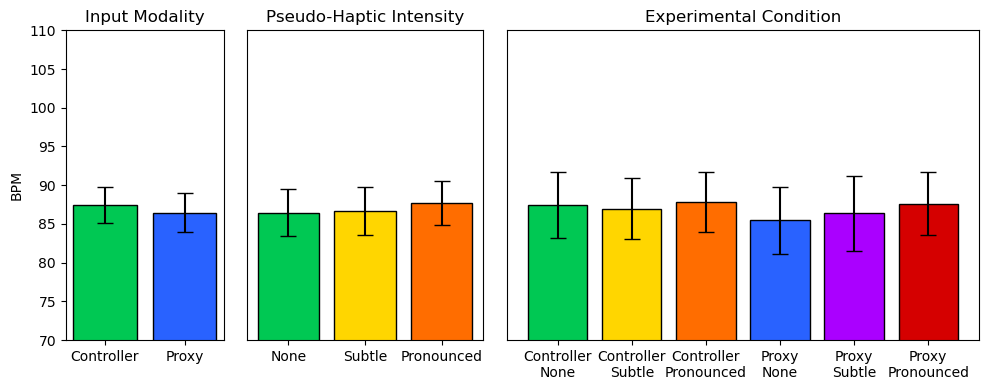

------ [Shovel] hr_mean_shovel ------
C0 & 93.18 & 14.16 & 61.86 & 121.12 \\
C1 & 94.2 & 14.57 & 66.55 & 128.96 \\
C2 & 94.52 & 13.1 & 67.0 & 127.8 \\
P0 & 93.51 & 13.67 & 66.67 & 122.36 \\
P1 & 94.1 & 12.87 & 63.94 & 124.36 \\
P2 & 94.8 & 14.14 & 63.62 & 131.6 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.744598,1,41,1.744598,0.113003,0.738465,0.738465,0.000037,1.000000,❌
1,Scaling,74.331556,2,82,37.165778,4.254019,0.017466,0.020602,0.001555,0.913955,✅
2,Device * Scaling,2.362663,2,82,1.181332,0.115325,0.891221,0.865074,0.000049,0.871837,❌


Device & (1, 41) & 0.11 & 7.4e-01 & 0.0 \\
Scaling & (2, 82) & 4.25 & \textbf{2.1e-02} & 0.0016 \\
Device * Scaling & (2, 82) & 0.12 & 8.7e-01 & 0.0 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-1.951651,41.0,two-sided,0.057834,0.115667,holm,0.934,-0.057982,❌
2,Scaling,-,0,2,True,True,-2.533125,41.0,two-sided,0.015226,0.045678,holm,2.802,-0.095011,✅
3,Scaling,-,1,2,True,True,-1.205087,41.0,two-sided,0.235079,0.235079,holm,0.327,-0.037449,❌


Scaling 1-0 & 41 & 1.95 & 1.2e-01 & 0.058 \\
Scaling 2-0 & 41 & 2.53 & \textbf{4.6e-02} & 0.095 \\
Scaling 2-1 & 41 & 1.21 & 2.4e-01 & 0.0374 \\
[70, 110]
[70, 110]
[70, 110]


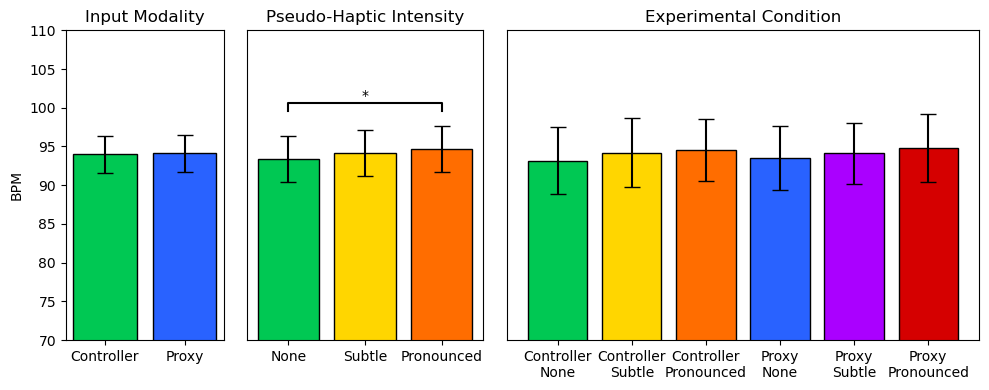

------ [Cube] hr_nauc_cube ------
C0 & 82.68 & 13.86 & 56.54 & 121.91 \\
C1 & 82.05 & 12.51 & 57.07 & 105.79 \\
C2 & 83.21 & 12.22 & 60.23 & 109.87 \\
P0 & 81.16 & 15.05 & 55.59 & 123.0 \\
P1 & 81.47 & 15.48 & 53.48 & 127.49 \\
P2 & 83.39 & 12.99 & 56.57 & 113.6 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,25.646150,1,41,25.646150,0.771243,0.384950,0.384950,0.000539,1.000000,❌
1,Scaling,120.876697,2,82,60.438348,1.506201,0.227821,0.230222,0.002534,0.809598,❌
2,Device * Scaling,30.375726,2,82,15.187863,0.299987,0.741637,0.710362,0.000638,0.866846,❌


Device & (1, 41) & 0.77 & 3.8e-01 & 0.0005 \\
Scaling & (2, 82) & 1.51 & 2.3e-01 & 0.0025 \\
Device * Scaling & (2, 82) & 0.3 & 7.1e-01 & 0.0006 \\
[70, 110]
[70, 110]
[70, 110]


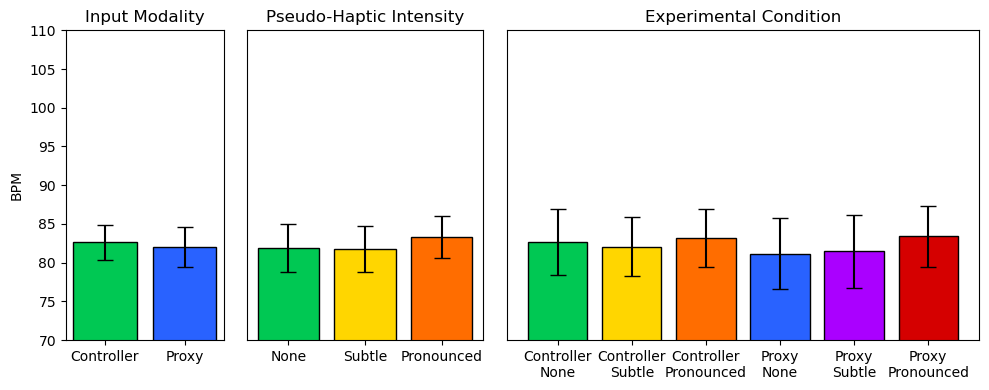

------ [Shovel] hr_nauc_shovel ------
C0 & 91.79 & 14.03 & 61.12 & 119.75 \\
C1 & 93.06 & 14.37 & 65.45 & 127.49 \\
C2 & 93.56 & 12.98 & 66.44 & 125.43 \\
P0 & 92.27 & 13.59 & 64.92 & 121.51 \\
P1 & 92.8 & 12.68 & 62.33 & 122.43 \\
P2 & 93.73 & 14.11 & 62.7 & 130.34 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.102022,1,41,1.102022,0.066596,0.797649,0.797649,0.000024,1.000000,❌
1,Scaling,109.839807,2,82,54.919904,6.426979,0.002553,0.003781,0.002338,0.889062,✅
2,Device * Scaling,5.830397,2,82,2.915199,0.286238,0.751831,0.724685,0.000124,0.883706,❌


Device & (1, 41) & 0.07 & 8.0e-01 & 0.0 \\
Scaling & (2, 82) & 6.43 & \textbf{3.8e-03} & 0.0023 \\
Device * Scaling & (2, 82) & 0.29 & 7.2e-01 & 0.0001 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.306186,41.0,two-sided,0.026231,0.052461,holm,1.777,-0.065309,🟨
2,Scaling,-,0,2,True,True,-3.092804,41.0,two-sided,0.003561,0.010683,holm,9.794,-0.117033,✅
3,Scaling,-,1,2,True,True,-1.658981,41.0,two-sided,0.104752,0.104752,holm,0.588,-0.052761,❌


Scaling 1-0 & 41 & 2.31 & 5.2e-02 & 0.0653 \\
Scaling 2-0 & 41 & 3.09 & \textbf{1.1e-02} & 0.117 \\
Scaling 2-1 & 41 & 1.66 & 1.0e-01 & 0.0528 \\
[70, 110]
[70, 110]
[70, 110]


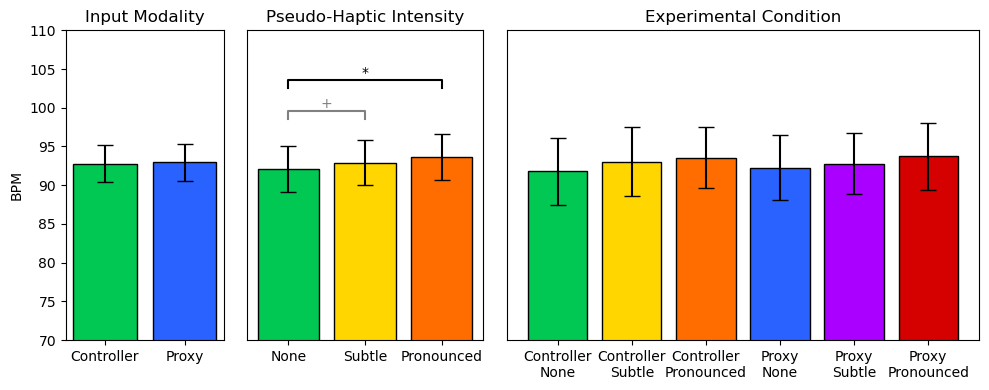

------ [Cube] hr_peak_cube ------
C0 & 91.54 & 13.56 & 66.0 & 127.0 \\
C1 & 91.23 & 12.52 & 67.9 & 122.0 \\
C2 & 92.37 & 12.69 & 66.6 & 120.7 \\
P0 & 90.02 & 13.76 & 61.4 & 127.0 \\
P1 & 91.02 & 15.08 & 59.0 & 136.0 \\
P2 & 93.01 & 13.3 & 67.3 & 125.4 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,8.215278,1,41,8.215278,0.187465,0.667304,0.667304,0.000179,1.000000,❌
1,Scaling,174.018175,2,82,87.009087,1.990759,0.143139,0.144853,0.003768,0.966417,❌
2,Device * Scaling,49.475317,2,82,24.737659,0.478695,0.621312,0.601336,0.001074,0.899111,❌


Device & (1, 41) & 0.19 & 6.7e-01 & 0.0002 \\
Scaling & (2, 82) & 1.99 & 1.4e-01 & 0.0038 \\
Device * Scaling & (2, 82) & 0.48 & 6.0e-01 & 0.0011 \\
[70, 110]
[70, 110]
[70, 110]


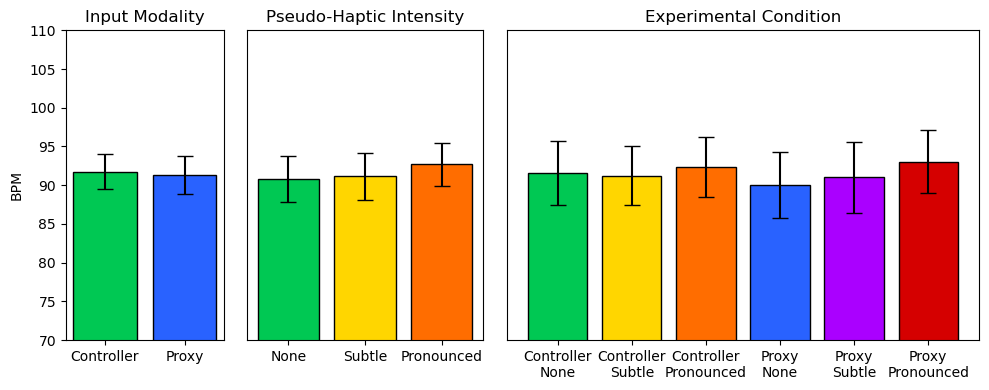

------ [Shovel] hr_peak_shovel ------
C0 & 100.13 & 13.94 & 72.0 & 133.0 \\
C1 & 101.05 & 14.64 & 72.0 & 142.0 \\
C2 & 101.36 & 13.08 & 73.0 & 141.0 \\
P0 & 101.34 & 13.46 & 73.0 & 136.0 \\
P1 & 101.86 & 13.19 & 73.0 & 139.0 \\
P2 & 101.66 & 14.68 & 66.8 & 147.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,37.568611,1,41,37.568611,1.478322,0.230992,0.230992,0.000777,1.000000,❌
1,Scaling,31.637143,2,82,15.818571,1.094080,0.339685,0.334803,0.000654,0.897272,❌
2,Device * Scaling,8.735556,2,82,4.367778,0.349525,0.706068,0.659847,0.000181,0.805302,❌


Device & (1, 41) & 1.48 & 2.3e-01 & 0.0008 \\
Scaling & (2, 82) & 1.09 & 3.3e-01 & 0.0007 \\
Device * Scaling & (2, 82) & 0.35 & 6.6e-01 & 0.0002 \\
[70, 110]
[70, 110]
[70, 110]


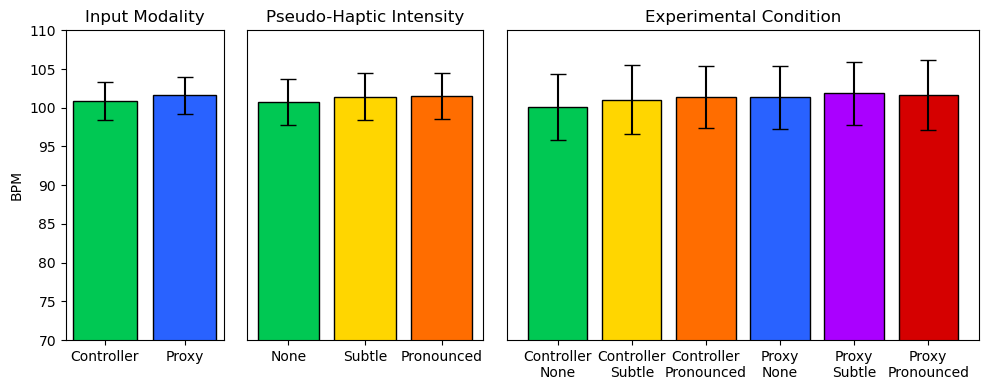

------ [Cube] hr_delta_cube ------
C0 & 7.48 & 5.52 & 0.0 & 24.0 \\
C1 & 7.69 & 5.27 & 1.0 & 25.0 \\
C2 & 8.47 & 6.78 & 1.0 & 26.0 \\
P0 & 8.41 & 5.94 & 0.7 & 26.3 \\
P1 & 8.53 & 6.15 & 1.0 & 23.9 \\
P2 & 9.57 & 5.97 & 1.0 & 24.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,57.620040,1,41,57.620040,2.119090,0.153088,0.153088,0.006404,1.000000,❌
1,Scaling,56.204127,2,82,28.102063,1.053434,0.353409,0.352079,0.006248,0.974475,❌
2,Device * Scaling,0.748889,2,82,0.374444,0.017992,0.982172,0.965451,0.000084,0.809858,❌


Device & (1, 41) & 2.12 & 1.5e-01 & 0.0064 \\
Scaling & (2, 82) & 1.05 & 3.5e-01 & 0.0062 \\
Device * Scaling & (2, 82) & 0.02 & 9.7e-01 & 0.0001 \\
[0, 25]
[0, 25]
[0, 25]


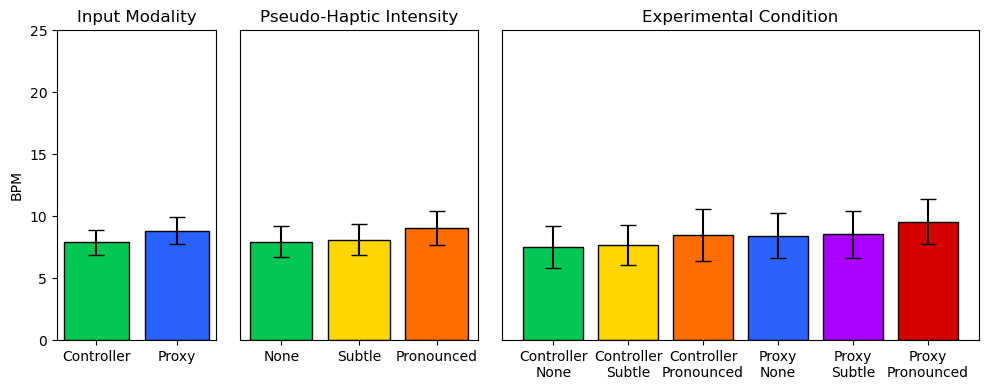

------ [Shovel] hr_delta_shovel ------
C0 & 16.86 & 6.78 & 7.0 & 34.0 \\
C1 & 16.6 & 6.74 & 3.0 & 34.0 \\
C2 & 16.74 & 6.75 & 5.0 & 36.0 \\
P0 & 17.9 & 7.67 & 3.0 & 35.0 \\
P1 & 19.73 & 6.73 & 10.0 & 38.0 \\
P2 & 17.3 & 7.84 & 5.4 & 38.0 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,156.200635,1,41,156.200635,4.834828,0.033589,0.033589,0.012141,1.000000,✅
1,Scaling,57.386270,2,82,28.693135,1.416168,0.248513,0.248755,0.004495,0.959115,❌
2,Device * Scaling,77.773889,2,82,38.886944,1.392907,0.254166,0.254271,0.006082,0.966643,❌


Device & (1, 41) & 4.83 & \textbf{3.4e-02} & 0.0121 \\
Scaling & (2, 82) & 1.42 & 2.5e-01 & 0.0045 \\
Device * Scaling & (2, 82) & 1.39 & 2.5e-01 & 0.0061 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.198824,41.0,two-sided,0.033589,NaN,NaN,1.449,-0.261467,✅


Device P-C & 41 & 2.2 & \textbf{3.4e-02} & 0.2615 \\
[0, 25]
[0, 25]
[0, 25]


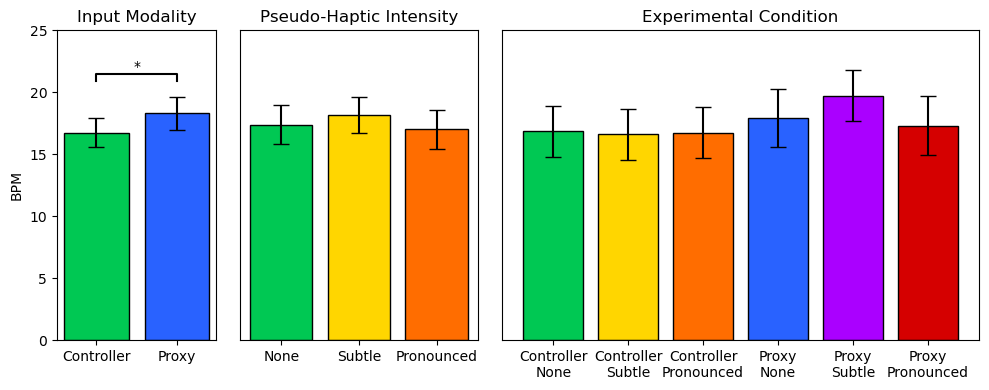

{'aov':              Source          SS  ddof1  ddof2          MS         F     p-unc  \
 0            Device  156.200635      1     41  156.200635  4.834828  0.033589   
 1           Scaling   57.386270      2     82   28.693135  1.416168  0.248513   
 2  Device * Scaling   77.773889      2     82   38.886944  1.392907  0.254166   
 
    p-GG-corr       ng2       eps Significance  
 0   0.033589  0.012141  1.000000            ✅  
 1   0.248755  0.004495  0.959115            ❌  
 2   0.254271  0.006082  0.966643            ❌  ,
 'pairwise':   Contrast Device  A  B Paired Parametric         T   dof alternative  \
 0   Device      -  C  P   True       True -2.198824  41.0   two-sided   
 
       p-unc  p-corr p-adjust   BF10    hedges Significance  
 0  0.033589     NaN      NaN  1.449 -0.261467            ✅  }

In [50]:
ylabel = 'BPM'
ylim_hr = [70, 110]

def hr_mean(p): return mean_val(p, hr_key)
report_exeriment(data, hr_mean, cube, "hr_mean_cube", ylabel, ylim_hr)
report_exeriment(data, hr_mean, shovel, "hr_mean_shovel", ylabel, ylim_hr)

def hr_auc(p): return normalized_auc(p, hr_key)
report_exeriment(data, hr_auc, cube, "hr_nauc_cube", ylabel, ylim_hr)
report_exeriment(data, hr_auc, shovel, "hr_nauc_shovel", ylabel, ylim_hr)

def hr_peak(p): return peak_val(p, hr_key)
report_exeriment(data, hr_peak, cube, "hr_peak_cube", ylabel, ylim_hr)
report_exeriment(data, hr_peak, shovel, "hr_peak_shovel", ylabel, ylim_hr)

ylim_hr_delta = [0, 25]
def hr_delta(p): return delta_val(p, hr_key)
report_exeriment(data, hr_delta, cube, "hr_delta_cube", ylabel, ylim_hr_delta)
report_exeriment(data, hr_delta, shovel, "hr_delta_shovel", ylabel, ylim_hr_delta)

------ [Cube] gsr_mean_cube ------
C0 & 7.04 & 4.87 & 1.17 & 18.51 \\
C1 & 7.36 & 5.54 & 1.44 & 20.06 \\
C2 & 7.09 & 5.32 & 1.81 & 22.62 \\
P0 & 6.52 & 3.95 & 0.95 & 18.23 \\
P1 & 6.35 & 4.26 & 1.18 & 18.32 \\
P2 & 7.43 & 5.9 & 1.53 & 24.07 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,9.795457,1,41,9.795457,2.968790,0.092421,0.092421,0.001540,1.000000,🟨
1,Scaling,11.349200,2,82,5.674600,1.343702,0.266561,0.260088,0.001784,0.629555,❌
2,Device * Scaling,19.859480,2,82,9.929740,3.044654,0.053029,0.077172,0.003117,0.639080,🟨


Device & (1, 41) & 2.97 & 9.2e-02 & 0.0015 \\
Scaling & (2, 82) & 1.34 & 2.6e-01 & 0.0018 \\
Device * Scaling & (2, 82) & 3.04 & 7.7e-02 & 0.0031 \\
[0, 15]
[0, 15]
[0, 15]


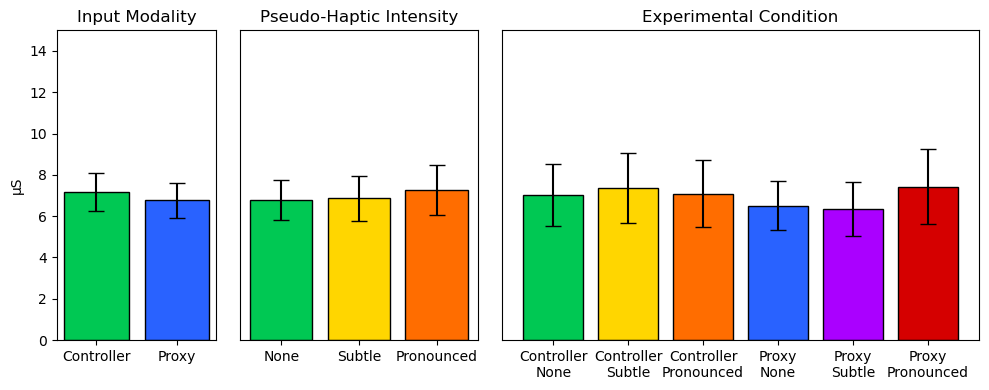

------ [Shovel] gsr_mean_shovel ------
C0 & 11.25 & 6.53 & 2.74 & 28.53 \\
C1 & 11.19 & 6.81 & 2.81 & 30.56 \\
C2 & 11.0 & 6.29 & 2.84 & 30.92 \\
P0 & 11.18 & 5.85 & 2.83 & 27.0 \\
P1 & 11.14 & 5.81 & 2.71 & 28.81 \\
P2 & 11.4 & 6.64 & 2.68 & 29.08 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.553842,1,41,0.553842,0.354366,0.554924,0.554924,0.000055,1.000000,❌
1,Scaling,0.099651,2,82,0.049825,0.049382,0.951846,0.882025,0.000010,0.646207,❌
2,Device * Scaling,2.886870,2,82,1.443435,1.189137,0.309679,0.288961,0.000285,0.574847,❌


Device & (1, 41) & 0.35 & 5.5e-01 & 0.0001 \\
Scaling & (2, 82) & 0.05 & 8.8e-01 & 0.0 \\
Device * Scaling & (2, 82) & 1.19 & 2.9e-01 & 0.0003 \\
[0, 15]
[0, 15]
[0, 15]


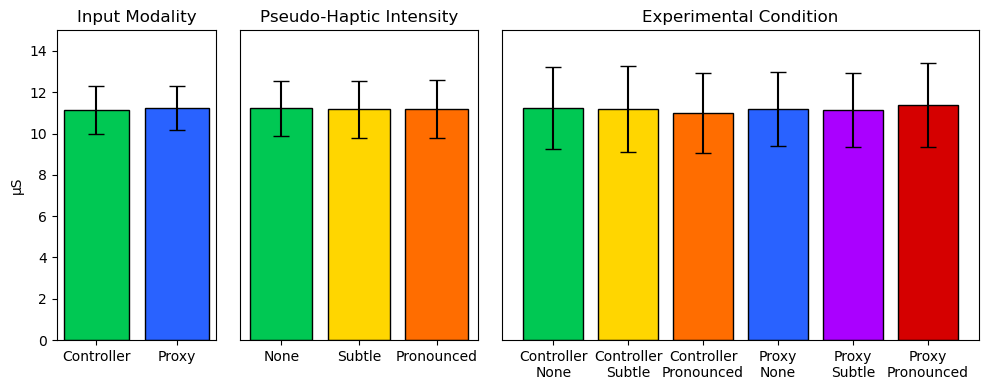

------ [Cube] gsr_nauc_cube ------
C0 & 7.03 & 4.87 & 1.17 & 18.5 \\
C1 & 7.36 & 5.53 & 1.44 & 20.05 \\
C2 & 7.08 & 5.32 & 1.81 & 22.61 \\
P0 & 6.51 & 3.94 & 0.95 & 18.22 \\
P1 & 6.35 & 4.26 & 1.18 & 18.31 \\
P2 & 7.43 & 5.9 & 1.53 & 24.06 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,9.765031,1,41,9.765031,2.965431,0.092599,0.092599,0.001537,1.000000,🟨
1,Scaling,11.354241,2,82,5.677120,1.345760,0.266030,0.259679,0.001786,0.629590,❌
2,Device * Scaling,19.842592,2,82,9.921296,3.046500,0.052938,0.077062,0.003118,0.639251,🟨


Device & (1, 41) & 2.97 & 9.3e-02 & 0.0015 \\
Scaling & (2, 82) & 1.35 & 2.6e-01 & 0.0018 \\
Device * Scaling & (2, 82) & 3.05 & 7.7e-02 & 0.0031 \\
[0, 15]
[0, 15]
[0, 15]


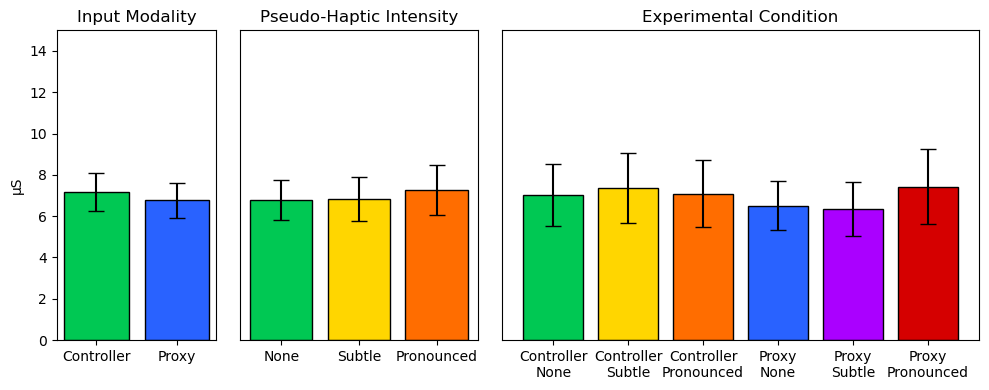

------ [Shovel] gsr_nauc_shovel ------
C0 & 11.25 & 6.53 & 2.74 & 28.53 \\
C1 & 11.19 & 6.81 & 2.81 & 30.56 \\
C2 & 11.0 & 6.29 & 2.84 & 30.91 \\
P0 & 11.18 & 5.85 & 2.83 & 26.99 \\
P1 & 11.14 & 5.81 & 2.71 & 28.81 \\
P2 & 11.4 & 6.64 & 2.68 & 29.07 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.553750,1,41,0.553750,0.354369,0.554922,0.554922,0.000055,1.000000,❌
1,Scaling,0.099541,2,82,0.049770,0.049350,0.951876,0.882070,0.000010,0.646199,❌
2,Device * Scaling,2.883409,2,82,1.441704,1.188249,0.309947,0.289162,0.000285,0.574937,❌


Device & (1, 41) & 0.35 & 5.5e-01 & 0.0001 \\
Scaling & (2, 82) & 0.05 & 8.8e-01 & 0.0 \\
Device * Scaling & (2, 82) & 1.19 & 2.9e-01 & 0.0003 \\
[0, 15]
[0, 15]
[0, 15]


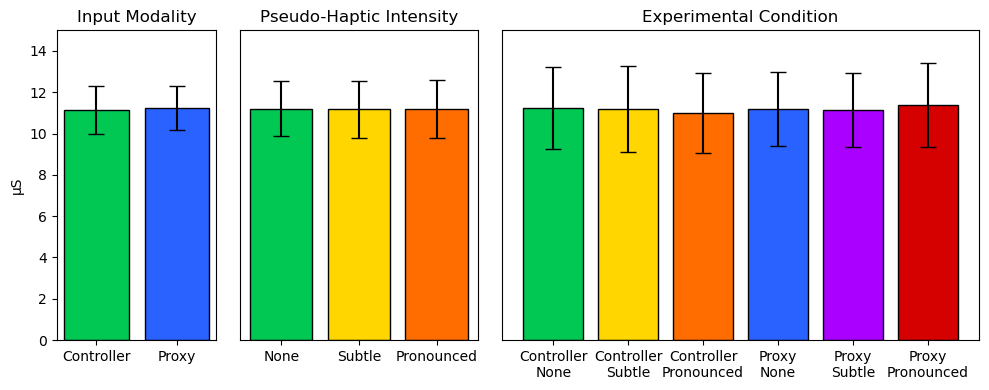

------ [Cube] gsr_peak_cube ------
C0 & 7.27 & 5.0 & 1.24 & 19.12 \\
C1 & 7.61 & 5.66 & 1.46 & 20.65 \\
C2 & 7.42 & 5.55 & 1.85 & 23.93 \\
P0 & 6.93 & 4.11 & 1.01 & 18.83 \\
P1 & 6.74 & 4.41 & 1.57 & 19.08 \\
P2 & 7.91 & 6.13 & 1.61 & 25.53 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,3.568752,1,41,3.568752,1.232539,0.273383,0.273383,0.000525,1.000000,❌
1,Scaling,15.740759,2,82,7.870379,1.733870,0.183011,0.194325,0.002311,0.620245,❌
2,Device * Scaling,20.084506,2,82,10.042253,2.989213,0.055840,0.076141,0.002947,0.691073,🟨


Device & (1, 41) & 1.23 & 2.7e-01 & 0.0005 \\
Scaling & (2, 82) & 1.73 & 1.9e-01 & 0.0023 \\
Device * Scaling & (2, 82) & 2.99 & 7.6e-02 & 0.0029 \\
[0, 15]
[0, 15]
[0, 15]


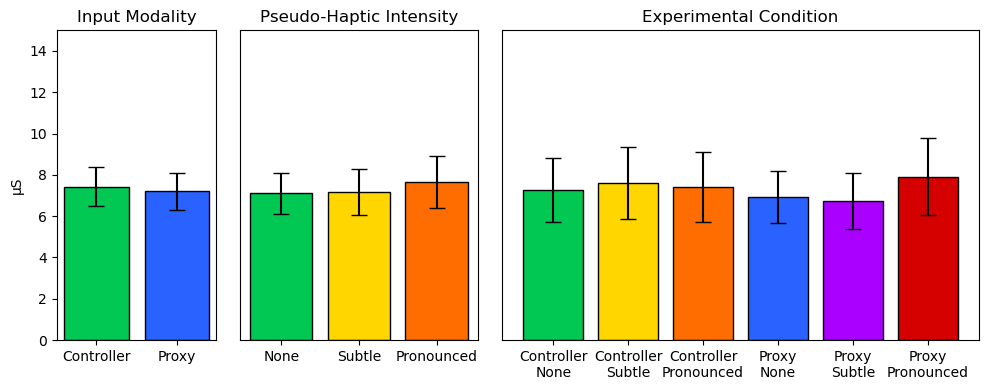

------ [Shovel] gsr_peak_shovel ------
C0 & 11.75 & 6.84 & 2.85 & 30.16 \\
C1 & 11.7 & 7.1 & 2.9 & 32.38 \\
C2 & 11.55 & 6.61 & 2.97 & 32.86 \\
P0 & 11.77 & 6.1 & 2.96 & 28.74 \\
P1 & 11.79 & 6.16 & 2.86 & 31.73 \\
P2 & 12.02 & 6.88 & 2.77 & 30.09 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.431900,1,41,2.431900,1.582693,0.215491,0.215491,0.000220,1.000000,❌
1,Scaling,0.064584,2,82,0.032292,0.027164,0.973210,0.934738,0.000006,0.712520,❌
2,Device * Scaling,2.400484,2,82,1.200242,0.859115,0.427313,0.377138,0.000217,0.595581,❌


Device & (1, 41) & 1.58 & 2.2e-01 & 0.0002 \\
Scaling & (2, 82) & 0.03 & 9.3e-01 & 0.0 \\
Device * Scaling & (2, 82) & 0.86 & 3.8e-01 & 0.0002 \\
[0, 15]
[0, 15]
[0, 15]


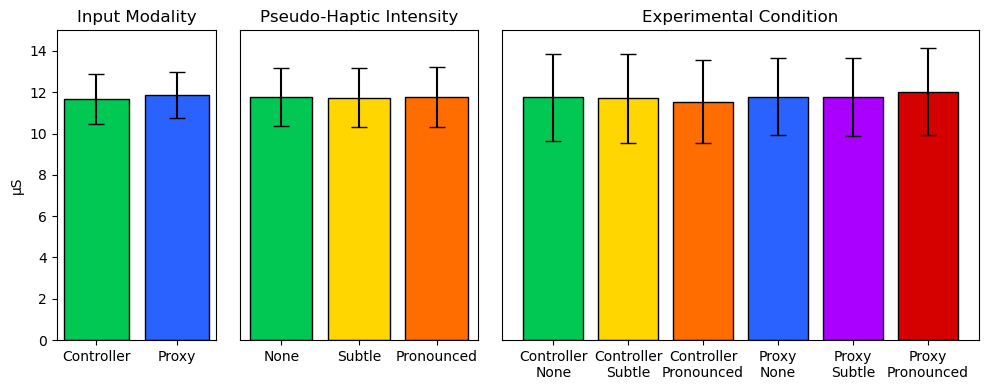

------ [Cube] gsr_delta_cube ------
C0 & 0.46 & 0.31 & 0.09 & 1.49 \\
C1 & 0.49 & 0.41 & 0.05 & 1.99 \\
C2 & 0.67 & 0.86 & 0.05 & 4.34 \\
P0 & 0.83 & 0.74 & 0.14 & 2.75 \\
P1 & 0.79 & 0.66 & 0.05 & 3.05 \\
P2 & 0.92 & 0.74 & 0.12 & 3.17 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,5.734525,1,41,5.734525,13.064400,0.000815,0.000815,0.051081,1.000000,✅
1,Scaling,1.322656,2,82,0.661328,4.581205,0.012999,0.024303,0.012264,0.711015,✅
2,Device * Scaling,0.151884,2,82,0.075942,0.503197,0.606449,0.551287,0.001424,0.737726,❌


Device & (1, 41) & 13.06 & \textbf{8.2e-04} & 0.0511 \\
Scaling & (2, 82) & 4.58 & \textbf{2.4e-02} & 0.0123 \\
Device * Scaling & (2, 82) & 0.5 & 5.5e-01 & 0.0014 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.614471,41.0,two-sided,0.000815,NaN,NaN,36.108,-0.516777,✅
1,Scaling,-,0,1,True,True,0.242766,41.0,two-sided,0.809397,0.809397,holm,0.172,0.019148,❌
2,Scaling,-,0,2,True,True,-2.075600,41.0,two-sided,0.044243,0.088487,holm,1.158,-0.249575,🟨
3,Scaling,-,1,2,True,True,-2.575428,41.0,two-sided,0.013716,0.041147,holm,3.061,-0.261456,✅


Device P-C & 41 & 3.61 & \textbf{8.2e-04} & 0.5168 \\
Scaling 1-0 & 41 & -0.24 & 8.1e-01 & -0.0191 \\
Scaling 2-0 & 41 & 2.08 & 8.8e-02 & 0.2496 \\
Scaling 2-1 & 41 & 2.58 & \textbf{4.1e-02} & 0.2615 \\
[0, 2]
[0, 2]
[0, 2]


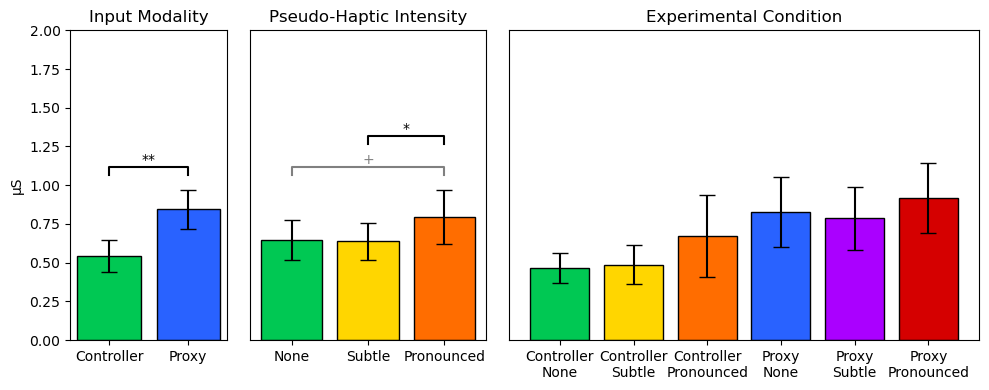

------ [Shovel] gsr_delta_shovel ------
C0 & 0.92 & 0.74 & 0.18 & 3.68 \\
C1 & 0.92 & 0.75 & 0.12 & 3.28 \\
C2 & 1.01 & 0.97 & 0.22 & 5.74 \\
P0 & 1.12 & 0.73 & 0.23 & 3.03 \\
P1 & 1.18 & 0.93 & 0.24 & 4.59 \\
P2 & 1.15 & 0.77 & 0.16 & 4.18 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,2.423546,1,41,2.423546,23.155965,0.000020,0.000020,0.014048,1.000000,✅
1,Scaling,0.134314,2,82,0.067157,0.309080,0.734974,0.720084,0.000789,0.933678,❌
2,Device * Scaling,0.130751,2,82,0.065375,0.347650,0.707382,0.689469,0.000768,0.919270,❌


Device & (1, 41) & 23.16 & \textbf{2.0e-05} & 0.014 \\
Scaling & (2, 82) & 0.31 & 7.2e-01 & 0.0008 \\
Device * Scaling & (2, 82) & 0.35 & 6.9e-01 & 0.0008 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.812065,41.0,two-sided,0.00002,NaN,NaN,1026.593,-0.260542,✅


Device P-C & 41 & 4.81 & \textbf{2.0e-05} & 0.2605 \\
[0, 2]
[0, 2]
[0, 2]


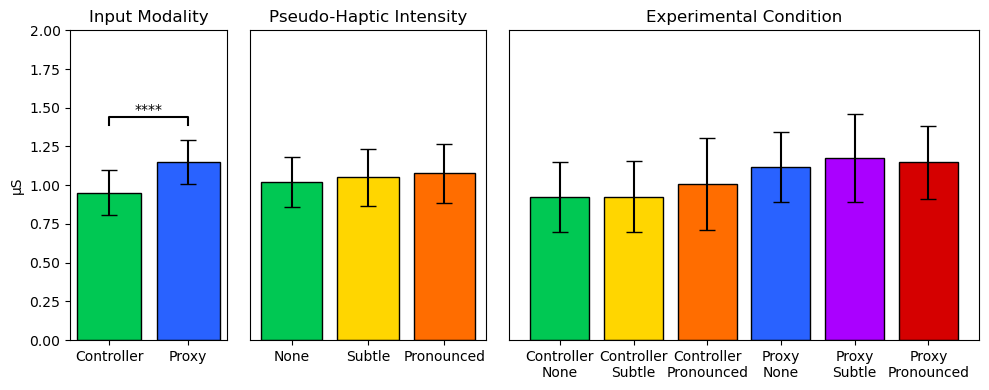

{'aov':              Source        SS  ddof1  ddof2        MS          F     p-unc  \
 0            Device  2.423546      1     41  2.423546  23.155965  0.000020   
 1           Scaling  0.134314      2     82  0.067157   0.309080  0.734974   
 2  Device * Scaling  0.130751      2     82  0.065375   0.347650  0.707382   
 
    p-GG-corr       ng2       eps Significance  
 0   0.000020  0.014048  1.000000            ✅  
 1   0.720084  0.000789  0.933678            ❌  
 2   0.689469  0.000768  0.919270            ❌  ,
 'pairwise':   Contrast Device  A  B Paired Parametric         T   dof alternative  \
 0   Device      -  C  P   True       True -4.812065  41.0   two-sided   
 
      p-unc  p-corr p-adjust      BF10    hedges Significance  
 0  0.00002     NaN      NaN  1026.593 -0.260542            ✅  }

In [51]:
ylabel = 'µS'
ylim_gsr = [0,15]

def gsr_con_mean(p): return mean_val(p, gsr_con_key)
report_exeriment(data, gsr_con_mean, cube, "gsr_mean_cube", ylabel, ylim_gsr)
report_exeriment(data, gsr_con_mean, shovel, "gsr_mean_shovel", ylabel, ylim_gsr)

def gsr_con_auc(p): return normalized_auc(p, gsr_con_key)
report_exeriment(data, gsr_con_auc, cube, "gsr_nauc_cube", ylabel, ylim_gsr)
report_exeriment(data, gsr_con_auc, shovel, "gsr_nauc_shovel", ylabel, ylim_gsr)

def gsr_con_peak(p): return peak_val(p, gsr_con_key)
report_exeriment(data, gsr_con_peak, cube, "gsr_peak_cube", ylabel, ylim_gsr)
report_exeriment(data, gsr_con_peak, shovel, "gsr_peak_shovel", ylabel, ylim_gsr)

ylim_gsr_delta = [0,2]
def gsr_con_delta(p): return delta_val(p, gsr_con_key)
report_exeriment(data, gsr_con_delta, cube, "gsr_delta_cube", ylabel, ylim_gsr_delta)
report_exeriment(data, gsr_con_delta, shovel, "gsr_delta_shovel", ylabel, ylim_gsr_delta)

------ [Cube] head_travel_transverse_cube ------
C0 & 9.66 & 2.4 & 6.6 & 17.65 \\
C1 & 9.81 & 2.29 & 6.29 & 17.61 \\
C2 & 10.41 & 2.87 & 6.25 & 21.01 \\
P0 & 9.62 & 1.82 & 6.14 & 13.74 \\
P1 & 9.55 & 1.4 & 7.03 & 13.38 \\
P2 & 10.48 & 2.88 & 7.03 & 20.69 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.363061,1,41,0.363061,0.070874,0.791403,0.791403,0.000263,1.000000,❌
1,Scaling,34.670013,2,82,17.335006,4.264748,0.017297,0.030365,0.024540,0.708431,✅
2,Device * Scaling,1.212477,2,82,0.606239,0.210658,0.810488,0.780898,0.000879,0.873515,❌


Device & (1, 41) & 0.07 & 7.9e-01 & 0.0003 \\
Scaling & (2, 82) & 4.26 & \textbf{3.0e-02} & 0.0245 \\
Device * Scaling & (2, 82) & 0.21 & 7.8e-01 & 0.0009 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-0.166594,41.0,two-sided,0.868508,0.868508,holm,0.169,-0.022469,❌
2,Scaling,-,0,2,True,True,-2.033604,41.0,two-sided,0.048498,0.096996,holm,1.075,-0.376538,🟨
3,Scaling,-,1,2,True,True,-2.704041,41.0,two-sided,0.009927,0.029782,holm,4.031,-0.379381,✅


Scaling 1-0 & 41 & 0.17 & 8.7e-01 & 0.0225 \\
Scaling 2-0 & 41 & 2.03 & 9.7e-02 & 0.3765 \\
Scaling 2-1 & 41 & 2.7 & \textbf{3.0e-02} & 0.3794 \\
[0, 20]
[0, 20]
[0, 20]


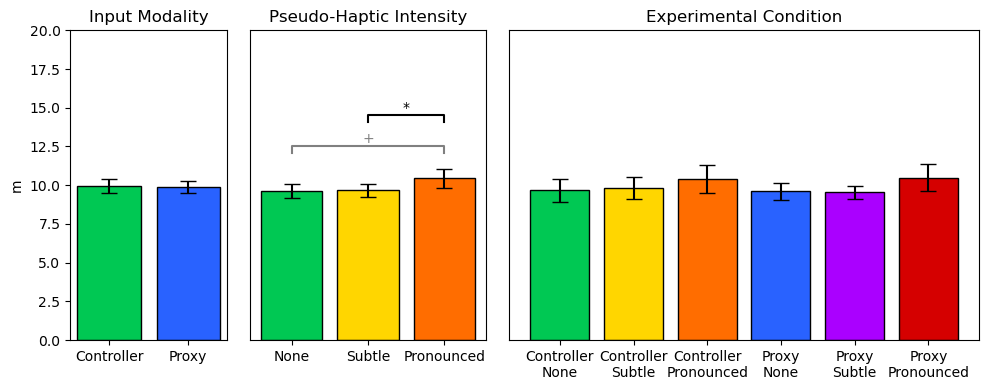

------ [Shovel] head_travel_transverse_shovel ------
C0 & 43.11 & 8.65 & 23.89 & 65.66 \\
C1 & 45.25 & 8.6 & 24.26 & 61.02 \\
C2 & 48.46 & 9.33 & 24.15 & 65.16 \\
P0 & 44.53 & 8.73 & 22.09 & 59.78 \\
P1 & 46.9 & 9.44 & 14.22 & 59.31 \\
P2 & 48.18 & 9.49 & 20.23 & 60.6 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,54.685583,1,41,54.685583,1.687070,0.201245,0.201245,0.002645,1.000000,❌
1,Scaling,852.526240,2,82,426.263120,13.524445,0.000008,0.000071,0.039700,0.756174,✅
2,Device * Scaling,46.651286,2,82,23.325643,1.110819,0.334193,0.322281,0.002257,0.766394,❌


Device & (1, 41) & 1.69 & 2.0e-01 & 0.0026 \\
Scaling & (2, 82) & 13.52 & \textbf{7.1e-05} & 0.0397 \\
Device * Scaling & (2, 82) & 1.11 & 3.2e-01 & 0.0023 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.892196,41.0,two-sided,0.006097,0.006097,holm,6.134,-0.271576,✅
2,Scaling,-,0,2,True,True,-4.165965,41.0,two-sided,0.000156,0.000467,holm,160.554,-0.523544,✅
3,Scaling,-,1,2,True,True,-3.268886,41.0,two-sided,0.002190,0.004380,holm,15.011,-0.259408,✅


Scaling 1-0 & 41 & 2.89 & \textbf{6.1e-03} & 0.2716 \\
Scaling 2-0 & 41 & 4.17 & \textbf{4.7e-04} & 0.5235 \\
Scaling 2-1 & 41 & 3.27 & \textbf{4.4e-03} & 0.2594 \\
[0, 80]
[0, 80]
[0, 80]


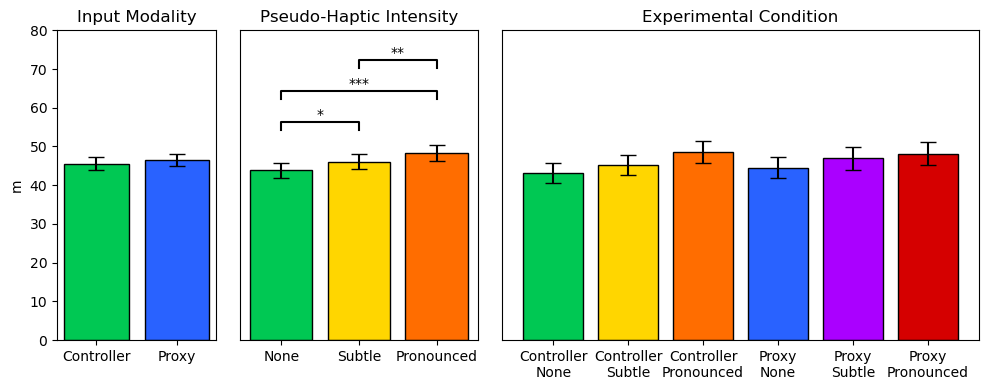

------ [Cube] head_travel_vertical_cube ------
C0 & 6.91 & 1.56 & 4.42 & 12.55 \\
C1 & 6.93 & 1.27 & 4.01 & 10.22 \\
C2 & 7.53 & 1.75 & 4.37 & 13.92 \\
P0 & 7.68 & 1.5 & 3.68 & 11.03 \\
P1 & 7.72 & 1.23 & 4.36 & 10.51 \\
P2 & 8.41 & 1.79 & 6.17 & 12.72 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,41.850918,1,41,41.850918,19.764167,0.000065,0.000065,0.065970,1.000000,✅
1,Scaling,24.512956,2,82,12.256478,5.655563,0.005001,0.013334,0.039726,0.670063,✅
2,Device * Scaling,0.132539,2,82,0.066269,0.048741,0.952456,0.936304,0.000224,0.882578,❌


Device & (1, 41) & 19.76 & \textbf{6.5e-05} & 0.066 \\
Scaling & (2, 82) & 5.66 & \textbf{1.3e-02} & 0.0397 \\
Device * Scaling & (2, 82) & 0.05 & 9.4e-01 & 0.0002 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.445691,41.0,two-sided,0.000065,NaN,NaN,354.274,-0.727242,✅
1,Scaling,-,0,1,True,True,-0.237071,41.0,two-sided,0.813782,0.813782,holm,0.171,-0.027898,❌
2,Scaling,-,0,2,True,True,-2.363435,41.0,two-sided,0.022929,0.045857,holm,1.987,-0.484753,✅
3,Scaling,-,1,2,True,True,-2.796993,41.0,two-sided,0.007819,0.023457,holm,4.948,-0.520394,✅


Device P-C & 41 & 4.45 & \textbf{6.5e-05} & 0.7272 \\
Scaling 1-0 & 41 & 0.24 & 8.1e-01 & 0.0279 \\
Scaling 2-0 & 41 & 2.36 & \textbf{4.6e-02} & 0.4848 \\
Scaling 2-1 & 41 & 2.8 & \textbf{2.3e-02} & 0.5204 \\
[0, 15]
[0, 15]
[0, 15]


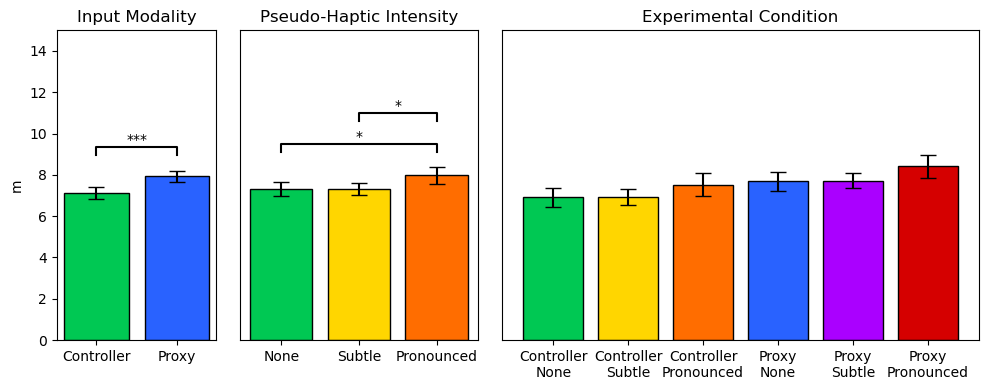

------ [Shovel] head_travel_vertical_shovel ------
C0 & 20.35 & 5.22 & 9.18 & 30.92 \\
C1 & 19.97 & 4.91 & 9.68 & 32.53 \\
C2 & 20.71 & 5.13 & 9.78 & 31.72 \\
P0 & 22.69 & 4.75 & 11.28 & 32.74 \\
P1 & 22.21 & 5.02 & 12.24 & 33.42 \\
P2 & 22.6 & 4.79 & 12.13 & 33.75 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,292.319374,1,41,292.319374,35.961107,4.372807e-07,4.372807e-07,0.044800,1.000000,✅
1,Scaling,14.509060,2,82,7.254530,0.770776,4.659764e-01,4.537427e-01,0.002323,0.899287,❌
2,Device * Scaling,2.332305,2,82,1.166152,0.178450,8.368900e-01,8.107167e-01,0.000374,0.884441,❌


Device & (1, 41) & 35.96 & \textbf{4.4e-07} & 0.0448 \\
Scaling & (2, 82) & 0.77 & 4.5e-01 & 0.0023 \\
Device * Scaling & (2, 82) & 0.18 & 8.1e-01 & 0.0004 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-5.996758,41.0,two-sided,4.372807e-07,NaN,NaN,3.659e+04,-0.477003,✅


Device P-C & 41 & 6.0 & \textbf{4.4e-07} & 0.477 \\
[0, 30]
[0, 30]
[0, 30]


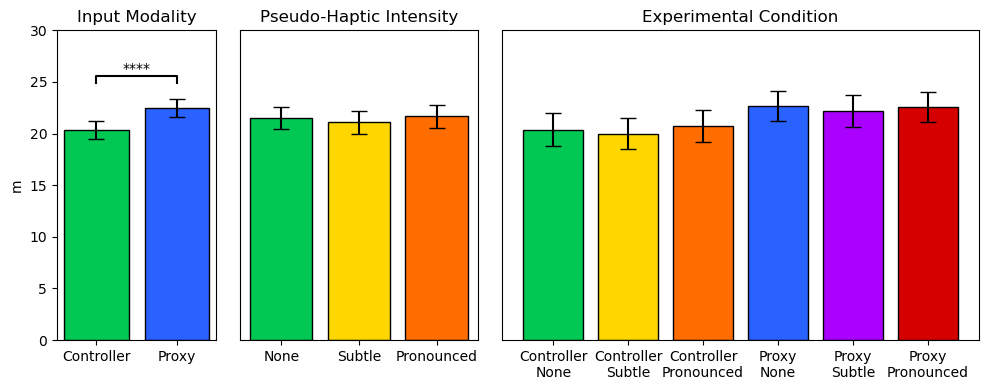

In [52]:
ylabel = 'm'

# title = '3D Head Travel'
# def hmd_path_len(p): return get_pt_path_len(p, hmd)
# cube_3d_travel = report_exeriment(data, hmd_path_len, cube, title, ylabel, ylim=[0,25])
# shovel_3d_travel = report_exeriment(data, hmd_path_len, shovel, title, ylabel, ylim=[0,90])

def hmd_path_len_planar(p): return get_pt_path_len_planar(p, hmd)
cube_planar_travel = report_exeriment(data, hmd_path_len_planar, cube, "head_travel_transverse_cube", ylabel, ylim=[0,20])
shovel_planar_travel = report_exeriment(data, hmd_path_len_planar, shovel, "head_travel_transverse_shovel", ylabel, ylim=[0,80])

def hmd_path_len_vertical(p): return get_pt_path_len_vertical(p, hmd)
cube_vert_travel = report_exeriment(data, hmd_path_len_vertical, cube, "head_travel_vertical_cube", ylabel, ylim=[0,15])
shovel_vert_travel = report_exeriment(data, hmd_path_len_vertical, shovel, "head_travel_vertical_shovel", ylabel, ylim=[0,30])

In [53]:
# def get_head_travel_splits(data, e):
#     total_travel = []
#     planar_travel = []
#     vert_travel = []

#     for c in conditions:
#         participant_values = list(map(lambda x: x[e][c], data))
#         participant_totals = list(map(lambda x: get_pt_path_len(x, hmd), participant_values))
#         participant_planars = list(map(lambda x: get_pt_path_len_planar(x, hmd), participant_values))
#         participant_verts = list(map(lambda x: get_pt_path_len_vertical(x, hmd), participant_values))

#         total_travel.append(np.mean(participant_totals))
#         planar_travel.append(np.mean(participant_planars))
#         vert_travel.append(np.mean(participant_verts))

#     return [vert_travel, planar_travel, total_travel]

# labels = ["Vertical", "Transverse", "3D"]
# ylabel = 'sec'

# cube_title = "[Cube] Head Travel"
# cube_travel_splits = get_head_travel_splits(data, cube)
# cube_travel_aovs = [cube_vert_travel, cube_planar_travel, cube_3d_travel]
# report_comparison(cube_travel_splits, cube_travel_aovs, labels, cube_title, ylabel)

# shovel_title = "[Shovel] Head Travel"
# shovel_travel_splits = get_head_travel_splits(data, shovel)
# shovel_travel_aovs = [shovel_vert_travel, shovel_planar_travel, shovel_3d_travel]
# report_comparison(shovel_travel_splits, shovel_travel_aovs, labels, shovel_title, ylabel)


------ [Shovel] grip_width ------
C0 & 383.61 & 73.99 & 242.92 & 539.79 \\
C1 & 407.09 & 80.87 & 217.45 & 609.24 \\
C2 & 427.34 & 75.11 & 251.55 & 590.03 \\
P0 & 438.95 & 50.34 & 313.7 & 540.31 \\
P1 & 457.24 & 47.26 & 348.81 & 542.19 \\
P2 & 460.84 & 47.28 & 349.05 & 536.68 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,135220.234960,1,41,135220.234960,21.845864,3.180166e-05,3.180166e-05,0.115486,1.000000,✅
1,Scaling,46328.995440,2,82,23164.497720,20.928004,4.536988e-08,2.173738e-07,0.042819,0.885321,✅
2,Device * Scaling,5467.706967,2,82,2733.853484,2.850314,6.357069e-02,7.162487e-02,0.005252,0.869571,🟨


Device & (1, 41) & 21.85 & \textbf{3.2e-05} & 0.1155 \\
Scaling & (2, 82) & 20.93 & \textbf{2.2e-07} & 0.0428 \\
Device * Scaling & (2, 82) & 2.85 & 7.2e-02 & 0.0053 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-4.673956,41.0,two-sided,0.000032,NaN,NaN,685.204,-0.773562,✅
1,Scaling,-,0,1,True,True,-4.212134,41.0,two-sided,0.000135,0.000270,holm,182.699,-0.384698,✅
2,Scaling,-,0,2,True,True,-5.520926,41.0,two-sided,0.000002,0.000006,holm,8564.456,-0.610009,✅
3,Scaling,-,1,2,True,True,-2.723940,41.0,two-sided,0.009436,0.009436,holm,4.211,-0.221618,✅


Device P-C & 41 & 4.67 & \textbf{3.2e-05} & 0.7736 \\
Scaling 1-0 & 41 & 4.21 & \textbf{2.7e-04} & 0.3847 \\
Scaling 2-0 & 41 & 5.52 & \textbf{6.2e-06} & 0.61 \\
Scaling 2-1 & 41 & 2.72 & \textbf{9.4e-03} & 0.2216 \\
[0, 700]
[0, 700]
[0, 700]


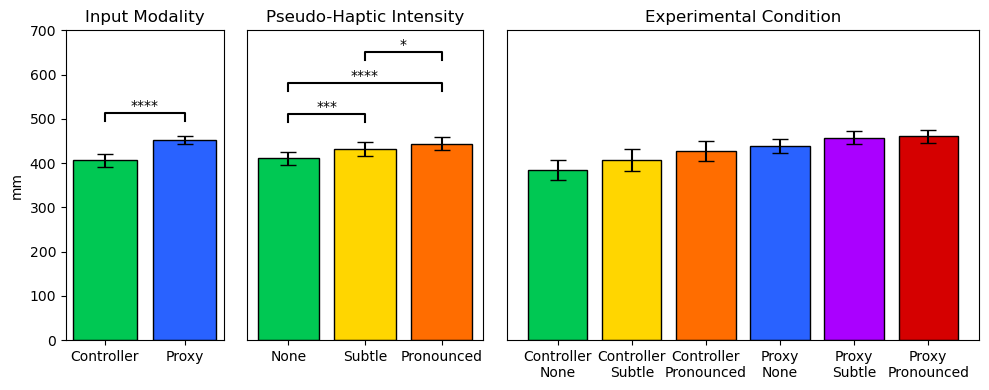

{'aov':              Source             SS  ddof1  ddof2             MS          F  \
 0            Device  135220.234960      1     41  135220.234960  21.845864   
 1           Scaling   46328.995440      2     82   23164.497720  20.928004   
 2  Device * Scaling    5467.706967      2     82    2733.853484   2.850314   
 
           p-unc     p-GG-corr       ng2       eps Significance  
 0  3.180166e-05  3.180166e-05  0.115486  1.000000            ✅  
 1  4.536988e-08  2.173738e-07  0.042819  0.885321            ✅  
 2  6.357069e-02  7.162487e-02  0.005252  0.869571            🟨  ,
 'pairwise':   Contrast Device  A  B Paired Parametric         T   dof alternative  \
 0   Device      -  C  P   True       True -4.673956  41.0   two-sided   
 1  Scaling      -  0  1   True       True -4.212134  41.0   two-sided   
 2  Scaling      -  0  2   True       True -5.520926  41.0   two-sided   
 3  Scaling      -  1  2   True       True -2.723940  41.0   two-sided   
 
       p-unc    p-corr p-a

In [54]:
primary_tracked = "pt"
secondary_tracked = "st"
primary_visible = "pv"
secondary_visible = "sv"

def mean_pt_dist(p, pt_1, pt_2):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    df["dist"] = df.apply(lambda x: distance.euclidean((x[pt_1 + "_x"], x[pt_1 + "_y"], x[pt_1 + "_z"]), (x[pt_2 + "_x"], x[pt_2 + "_y"], x[pt_2 + "_z"])), axis = 1)
    return df["dist"].mean()

def tracked_hand_dist_mm(p):
    return mean_pt_dist(p, primary_tracked, secondary_tracked) * 1_000

ylabel = "mm"
report_exeriment(data, tracked_hand_dist_mm, shovel, "grip_width", ylabel, ylim=[0,700])

------ [Cube] duration_total_cube ------
C0 & 21.5 & 9.84 & 9.04 & 51.69 \\
C1 & 20.94 & 8.62 & 10.36 & 55.26 \\
C2 & 23.64 & 10.24 & 10.18 & 49.97 \\
P0 & 22.54 & 8.43 & 9.6 & 47.29 \\
P1 & 22.52 & 5.87 & 13.19 & 37.93 \\
P2 & 26.12 & 10.83 & 13.43 & 57.51 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,182.927808,1,41,182.927808,2.978326,0.091917,0.091917,0.008656,1.000000,🟨
1,Scaling,509.542389,2,82,254.771194,4.594288,0.012847,0.023756,0.023743,0.717352,✅
2,Device * Scaling,22.108316,2,82,11.054158,0.253489,0.776694,0.729074,0.001054,0.807523,❌


Device & (1, 41) & 2.98 & 9.2e-02 & 0.0087 \\
Scaling & (2, 82) & 4.59 & \textbf{2.4e-02} & 0.0237 \\
Device * Scaling & (2, 82) & 0.25 & 7.3e-01 & 0.0011 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,0.286750,41.0,two-sided,0.775748,0.775748,holm,0.173,0.040120,❌
2,Scaling,-,0,2,True,True,-1.955991,41.0,two-sided,0.057303,0.114606,holm,0.94,-0.330199,❌
3,Scaling,-,1,2,True,True,-3.503763,41.0,two-sided,0.001124,0.003372,holm,27.112,-0.414565,✅


Scaling 1-0 & 41 & -0.29 & 7.8e-01 & -0.0401 \\
Scaling 2-0 & 41 & 1.96 & 1.1e-01 & 0.3302 \\
Scaling 2-1 & 41 & 3.5 & \textbf{3.4e-03} & 0.4146 \\
[0, 35]
[0, 35]
[0, 35]


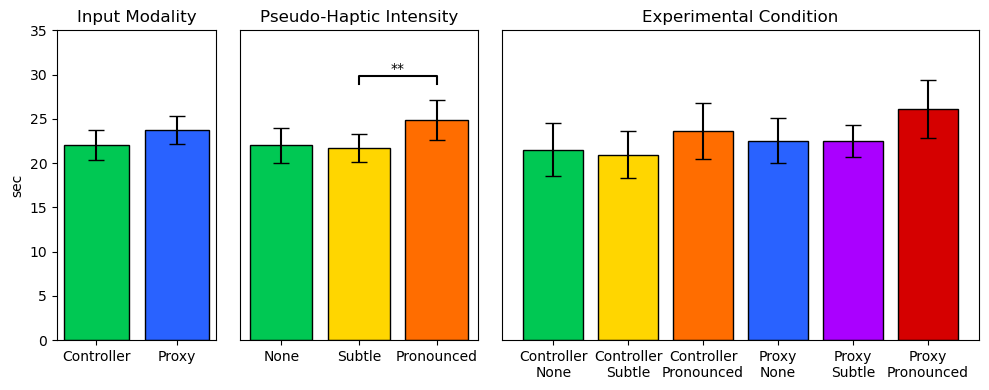

------ [Shovel] duration_total_shovel ------
C0 & 74.68 & 18.22 & 41.33 & 117.43 \\
C1 & 78.99 & 21.11 & 50.2 & 160.44 \\
C2 & 87.96 & 20.21 & 50.37 & 147.91 \\
P0 & 76.66 & 17.96 & 41.37 & 113.42 \\
P1 & 81.02 & 18.55 & 47.14 & 122.85 \\
P2 & 88.95 & 19.02 & 47.5 & 126.48 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,174.495364,1,41,174.495364,0.839379,0.364932,0.364932,0.001872,1.000000,❌
1,Scaling,7102.383999,2,82,3551.192000,15.168288,0.000002,0.000015,0.070940,0.815774,✅
2,Device * Scaling,14.563805,2,82,7.281902,0.039588,0.961204,0.925526,0.000157,0.760083,❌


Device & (1, 41) & 0.84 & 3.6e-01 & 0.0019 \\
Scaling & (2, 82) & 15.17 & \textbf{1.5e-05} & 0.0709 \\
Device * Scaling & (2, 82) & 0.04 & 9.3e-01 & 0.0002 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-2.012462,41.0,two-sided,0.050771,0.050771,holm,1.036,-0.263000,🟨
2,Scaling,-,0,2,True,True,-4.467527,41.0,two-sided,0.000061,0.000183,holm,377.161,-0.740061,✅
3,Scaling,-,1,2,True,True,-4.280168,41.0,two-sided,0.000109,0.000219,holm,221.251,-0.494258,✅


Scaling 1-0 & 41 & 2.01 & 5.1e-02 & 0.263 \\
Scaling 2-0 & 41 & 4.47 & \textbf{1.8e-04} & 0.7401 \\
Scaling 2-1 & 41 & 4.28 & \textbf{2.2e-04} & 0.4943 \\
[0, 150]
[0, 150]
[0, 150]


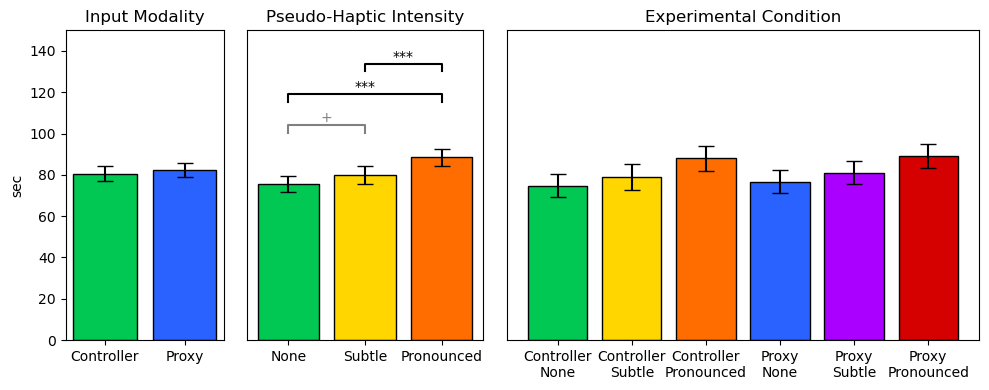

In [55]:
def task_duration(p):
    return (p[end_ts] - p[start_ts]) / 1_000

ylabel = 'sec'
cube_duration = report_exeriment(data, task_duration, cube, "duration_total_cube", ylabel, ylim=[0,35])
shovel_duration = report_exeriment(data, task_duration, shovel, "duration_total_shovel", ylabel, ylim=[0,150])

------ [Cube] duration_cube_no_barrier ------
C0 & 3.85 & 1.39 & 1.64 & 9.78 \\
C1 & 4.02 & 1.87 & 1.58 & 10.9 \\
C2 & 4.16 & 1.92 & 2.04 & 13.67 \\
P0 & 4.71 & 1.74 & 1.85 & 10.97 \\
P1 & 4.52 & 1.21 & 2.6 & 7.75 \\
P2 & 5.52 & 4.93 & 2.17 & 34.36 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,51.728071,1,41,51.728071,7.861990,0.007680,0.007680,0.031440,1.000000,✅
1,Scaling,17.706917,2,82,8.853458,1.697802,0.189457,0.198250,0.010989,0.696471,❌
2,Device * Scaling,7.758596,2,82,3.879298,0.620894,0.539971,0.472949,0.004845,0.643212,❌


Device & (1, 41) & 7.86 & \textbf{7.7e-03} & 0.0314 \\
Scaling & (2, 82) & 1.7 & 2.0e-01 & 0.011 \\
Device * Scaling & (2, 82) & 0.62 & 4.7e-01 & 0.0048 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.803924,41.0,two-sided,0.00768,NaN,NaN,5.025,-0.550788,✅


Device P-C & 41 & 2.8 & \textbf{7.7e-03} & 0.5508 \\
[0, 15]
[0, 15]
[0, 15]


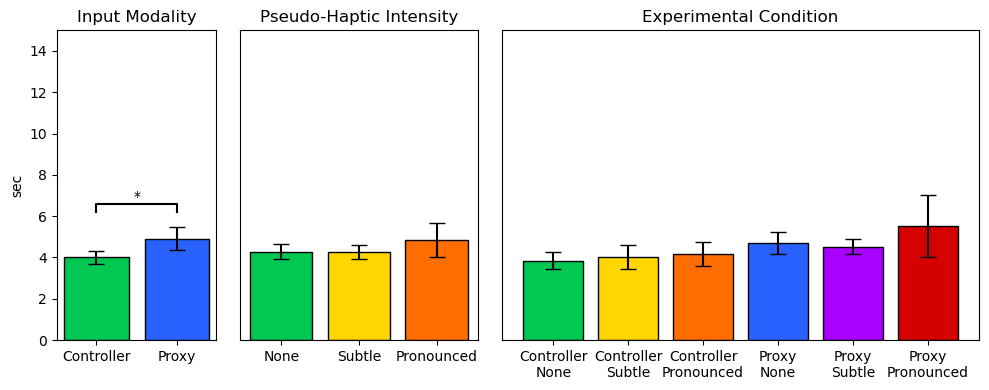

------ [Cube] duration_cube_medium_gap ------
C0 & 4.66 & 2.08 & 1.54 & 12.69 \\
C1 & 4.91 & 2.78 & 1.96 & 16.1 \\
C2 & 5.77 & 4.69 & 2.35 & 29.19 \\
P0 & 4.62 & 1.8 & 1.78 & 11.0 \\
P1 & 4.8 & 1.95 & 1.97 & 13.6 \\
P2 & 4.99 & 2.42 & 2.65 & 15.93 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,6.000789,1,41,6.000789,1.044895,0.312680,0.312680,0.003035,1.000000,❌
1,Scaling,24.331919,2,82,12.165959,2.200411,0.117256,0.129273,0.012194,0.794572,❌
2,Device * Scaling,6.875315,2,82,3.437658,0.827098,0.440931,0.419121,0.003476,0.807764,❌


Device & (1, 41) & 1.04 & 3.1e-01 & 0.003 \\
Scaling & (2, 82) & 2.2 & 1.3e-01 & 0.0122 \\
Device * Scaling & (2, 82) & 0.83 & 4.2e-01 & 0.0035 \\
[0, 15]
[0, 15]
[0, 15]


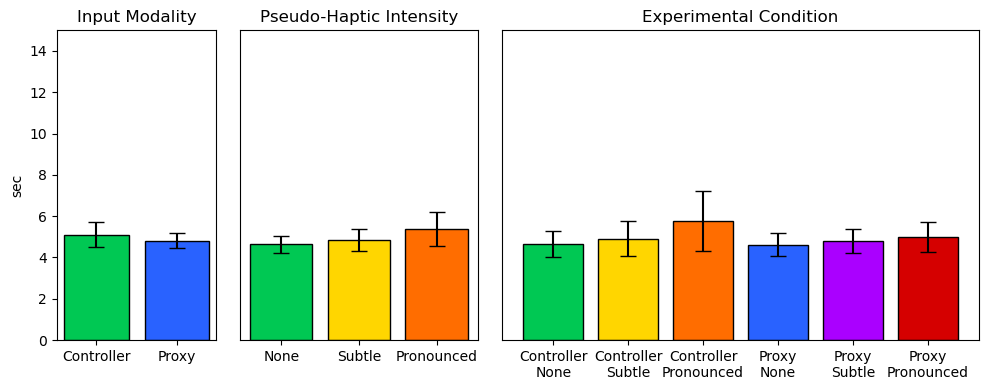

------ [Cube] duration_cube_low_gap ------
C0 & 6.32 & 5.47 & 1.87 & 26.34 \\
C1 & 5.66 & 3.41 & 2.06 & 17.51 \\
C2 & 6.15 & 3.74 & 2.12 & 16.75 \\
P0 & 5.58 & 3.64 & 1.92 & 20.99 \\
P1 & 5.36 & 2.02 & 2.39 & 10.73 \\
P2 & 7.23 & 5.44 & 2.67 & 26.17 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,0.016160,1,41,0.016160,0.000908,0.976109,0.976109,0.000004,1.000000,❌
1,Scaling,59.694881,2,82,29.847441,2.036516,0.137030,0.149660,0.013676,0.759533,❌
2,Device * Scaling,37.937940,2,82,18.968970,1.687544,0.191333,0.194037,0.008735,0.917295,❌


Device & (1, 41) & 0.0 & 9.8e-01 & 0.0 \\
Scaling & (2, 82) & 2.04 & 1.5e-01 & 0.0137 \\
Device * Scaling & (2, 82) & 1.69 & 1.9e-01 & 0.0087 \\
[0, 15]
[0, 15]
[0, 15]


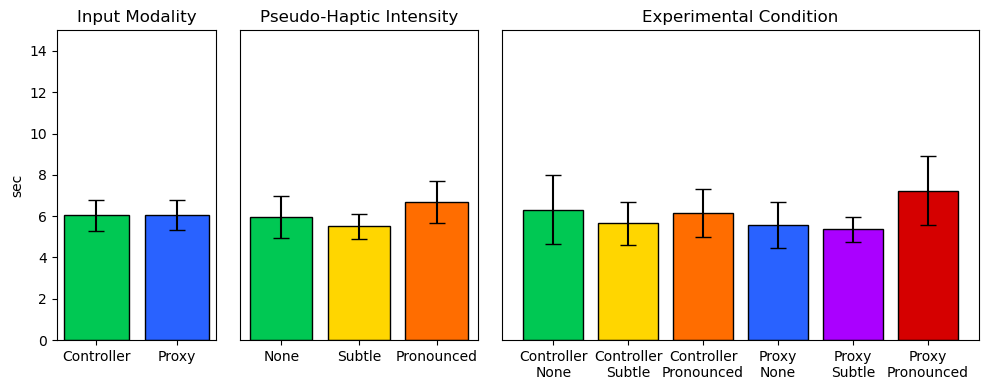

------ [Cube] duration_cube_high_gap ------
C0 & 6.58 & 2.5 & 3.14 & 13.22 \\
C1 & 6.26 & 2.54 & 3.29 & 15.96 \\
C2 & 7.48 & 3.32 & 3.08 & 18.1 \\
P0 & 7.55 & 3.09 & 3.96 & 23.16 \\
P1 & 7.76 & 2.05 & 4.18 & 13.57 \\
P2 & 8.29 & 2.67 & 4.21 & 17.93 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,75.160180,1,41,75.160180,15.917703,0.000267,0.000267,0.038639,1.000000,✅
1,Scaling,40.372807,2,82,20.186404,3.813254,0.026090,0.034997,0.021133,0.816239,✅
2,Device * Scaling,5.416871,2,82,2.708436,0.668588,0.515203,0.504155,0.002888,0.924583,❌


Device & (1, 41) & 15.92 & \textbf{2.7e-04} & 0.0386 \\
Scaling & (2, 82) & 3.81 & \textbf{3.5e-02} & 0.0211 \\
Device * Scaling & (2, 82) & 0.67 & 5.0e-01 & 0.0029 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-3.989700,41.0,two-sided,0.000267,NaN,NaN,98.592,-0.510919,✅
1,Scaling,-,0,1,True,True,0.166456,41.0,two-sided,0.868616,0.868616,holm,0.169,0.023516,❌
2,Scaling,-,0,2,True,True,-1.906594,41.0,two-sided,0.063598,0.127196,holm,0.866,-0.320176,❌
3,Scaling,-,1,2,True,True,-2.841588,41.0,two-sided,0.006963,0.020888,holm,5.468,-0.382761,✅


Device P-C & 41 & 3.99 & \textbf{2.7e-04} & 0.5109 \\
Scaling 1-0 & 41 & -0.17 & 8.7e-01 & -0.0235 \\
Scaling 2-0 & 41 & 1.91 & 1.3e-01 & 0.3202 \\
Scaling 2-1 & 41 & 2.84 & \textbf{2.1e-02} & 0.3828 \\
[0, 15]
[0, 15]
[0, 15]


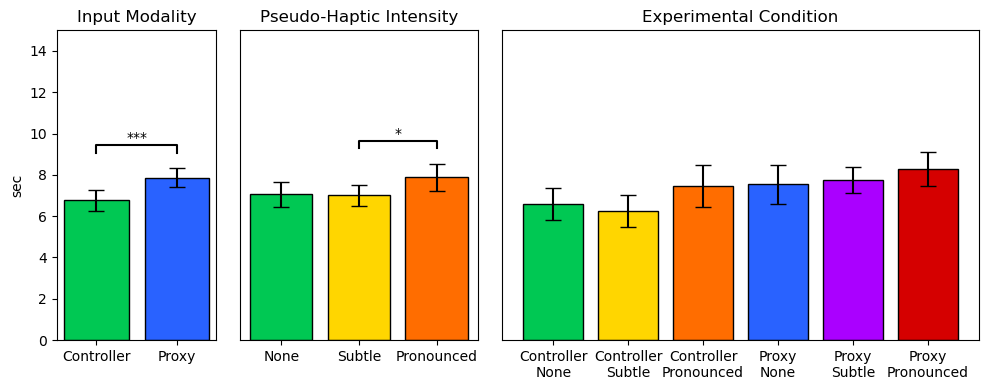

In [56]:
def single_target_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_time = first[unified_unix_key].max() - first[unified_unix_key].min()
    second_time = second[unified_unix_key].max() - second[unified_unix_key].min()
    third_time = third[unified_unix_key].max() - third[unified_unix_key].min()
    fourth_time = fourth[unified_unix_key].max() - fourth[unified_unix_key].min()

    return [first_time / 1_000, second_time / 1_000, third_time / 1_000, fourth_time / 1_000]

ylabel = "sec"
ylim=[0,15]

def single_first(p): return single_target_split(p)[0]
no_barrier_duration = report_exeriment(data, single_first, cube, "duration_cube_no_barrier", ylabel, ylim)

def single_third(p): return single_target_split(p)[2]
medium_barrier_duration = report_exeriment(data, single_third, cube, "duration_cube_medium_gap", ylabel, ylim)

def single_second(p): return single_target_split(p)[1]
low_barrier_duration = report_exeriment(data, single_second, cube, "duration_cube_low_gap", ylabel, ylim)

def single_fourth(p): return single_target_split(p)[3]
high_barrier_duration = report_exeriment(data, single_fourth, cube, "duration_cube_high_gap", ylabel, ylim)

------ duration_split_cube ------


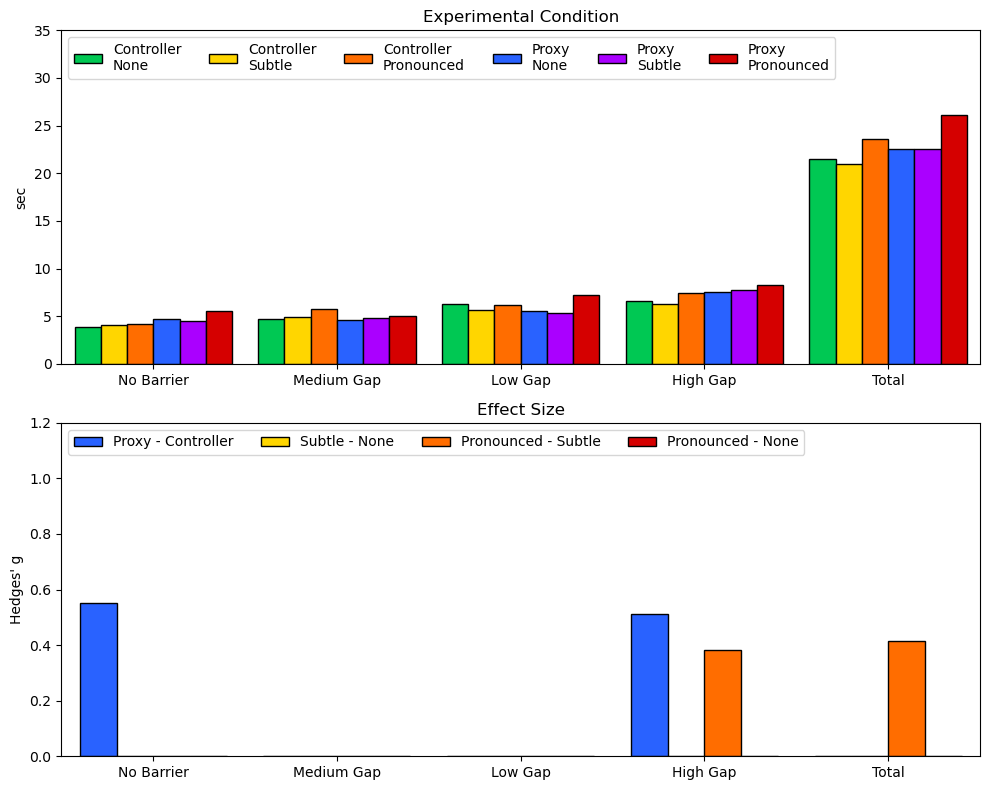

In [57]:
def get_cube_target_splits(data):
    total_durations = []
    no_barrier_durations = []
    medium_barrier_durations = []
    low_barrier_durations = []
    high_barrier_durations = []

    for c in conditions:
        participant_values = list(map(lambda x: x[cube][c], data))
        participant_totals = list(map(lambda x: task_duration(x), participant_values))
        participant_splits = list(map(lambda x: single_target_split(x), participant_values))

        total_durations.append(np.mean(participant_totals))

        no_barrier = list(map(lambda x: x[0],  participant_splits)) #No barrier is first target
        no_barrier_durations.append(np.mean(no_barrier))
        
        medium_barrier = list(map(lambda x: x[2],  participant_splits)) #Medium barrier is third taret (!)
        medium_barrier_durations.append(np.mean(medium_barrier))

        low_barrier = list(map(lambda x: x[1],  participant_splits)) #Low barrier is second target (!)
        low_barrier_durations.append(np.mean(low_barrier))

        high_barrier = list(map(lambda x: x[3],  participant_splits)) #High barrier is fourth target
        high_barrier_durations.append(np.mean(high_barrier))

    return [no_barrier_durations, medium_barrier_durations, low_barrier_durations, high_barrier_durations, total_durations]

target_labels = ["No Barrier", "Medium Gap", "Low Gap", "High Gap", "Total"]
ylabel='sec'
target_splits = get_cube_target_splits(data)
cube_duration_aovs = [no_barrier_duration, medium_barrier_duration, low_barrier_duration, high_barrier_duration, cube_duration]
report_comparison(target_splits, cube_duration_aovs, target_labels, "duration_split_cube", ylabel, ylim_condition=[0,35],ylim_eff=[0,1.2])


------ [Shovel] duration_shovel_unload ------
C0 & 33.79 & 7.2 & 18.47 & 49.15 \\
C1 & 34.67 & 8.32 & 21.68 & 64.46 \\
C2 & 37.22 & 7.01 & 24.59 & 53.78 \\
P0 & 35.74 & 7.81 & 19.01 & 51.09 \\
P1 & 36.47 & 8.32 & 21.97 & 61.47 \\
P2 & 39.49 & 9.41 & 18.83 & 59.81 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,253.783143,1,41,253.783143,5.819635,0.020407,0.020407,0.015293,1.000000,✅
1,Scaling,596.233330,2,82,298.116665,6.249929,0.002976,0.005059,0.035203,0.844454,✅
2,Device * Scaling,2.448700,2,82,1.224350,0.043354,0.957595,0.937373,0.000150,0.850618,❌


Device & (1, 41) & 5.82 & \textbf{2.0e-02} & 0.0153 \\
Scaling & (2, 82) & 6.25 & \textbf{5.1e-03} & 0.0352 \\
Device * Scaling & (2, 82) & 0.04 & 9.4e-01 & 0.0001 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
0,Device,-,C,P,True,True,-2.412392,41.0,two-sided,0.020407,NaN,NaN,2.19,-0.310149,✅
1,Scaling,-,0,1,True,True,-0.929222,41.0,two-sided,0.358213,0.358213,holm,0.25,-0.114614,❌
2,Scaling,-,0,2,True,True,-2.850946,41.0,two-sided,0.006794,0.020383,holm,5.585,-0.500862,✅
3,Scaling,-,1,2,True,True,-2.688841,41.0,two-sided,0.010319,0.020637,holm,3.9,-0.388330,✅


Device P-C & 41 & 2.41 & \textbf{2.0e-02} & 0.3101 \\
Scaling 1-0 & 41 & 0.93 & 3.6e-01 & 0.1146 \\
Scaling 2-0 & 41 & 2.85 & \textbf{2.0e-02} & 0.5009 \\
Scaling 2-1 & 41 & 2.69 & \textbf{2.1e-02} & 0.3883 \\
[0, 80]
[0, 80]
[0, 80]


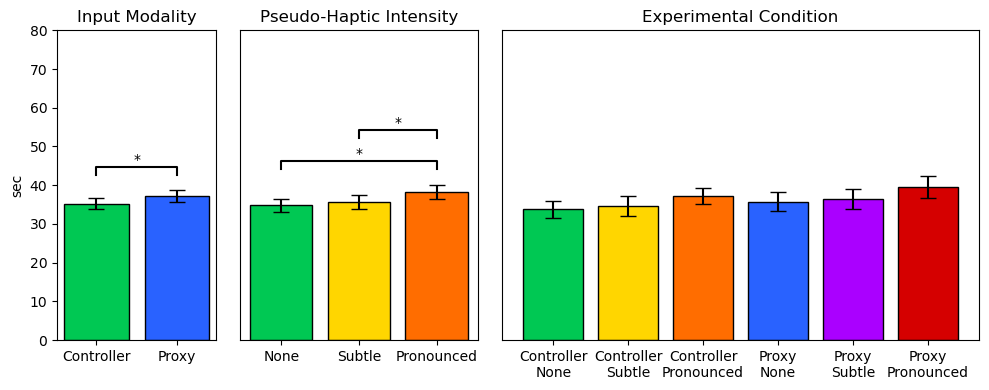

------ [Shovel] duration_shovel_load ------
C0 & 35.46 & 9.65 & 18.55 & 55.89 \\
C1 & 40.05 & 12.15 & 24.31 & 90.59 \\
C2 & 46.35 & 12.78 & 23.21 & 87.4 \\
P0 & 36.2 & 9.99 & 19.86 & 57.57 \\
P1 & 40.09 & 10.34 & 22.36 & 63.75 \\
P2 & 45.03 & 9.96 & 26.04 & 65.79 \\


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps,Significance
0,Device,1.995558,1,41,1.995558,0.036418,8.495975e-01,8.495975e-01,0.000067,1.000000,❌
1,Scaling,4114.775772,2,82,2057.387886,37.346902,2.946071e-12,1.260352e-10,0.121265,0.836623,✅
2,Device * Scaling,45.818095,2,82,22.909048,0.344485,7.096055e-01,6.459415e-01,0.001534,0.743362,❌


Device & (1, 41) & 0.04 & 8.5e-01 & 0.0001 \\
Scaling & (2, 82) & 37.35 & \textbf{1.3e-10} & 0.1213 \\
Device * Scaling & (2, 82) & 0.34 & 6.5e-01 & 0.0015 \\


,Contrast,Device,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges,Significance
1,Scaling,-,0,1,True,True,-4.072889,41.0,two-sided,2.070822e-04,2.070822e-04,holm,123.963,-0.468023,✅
2,Scaling,-,0,2,True,True,-7.182456,41.0,two-sided,9.118662e-09,2.735599e-08,holm,1.397e+06,-1.001847,✅
3,Scaling,-,1,2,True,True,-5.731193,41.0,two-sided,1.042990e-06,2.085980e-06,holm,1.624e+04,-0.575179,✅


Scaling 1-0 & 41 & 4.07 & \textbf{2.1e-04} & 0.468 \\
Scaling 2-0 & 41 & 7.18 & \textbf{2.7e-08} & 1.0018 \\
Scaling 2-1 & 41 & 5.73 & \textbf{2.1e-06} & 0.5752 \\
[0, 80]
[0, 80]
[0, 80]


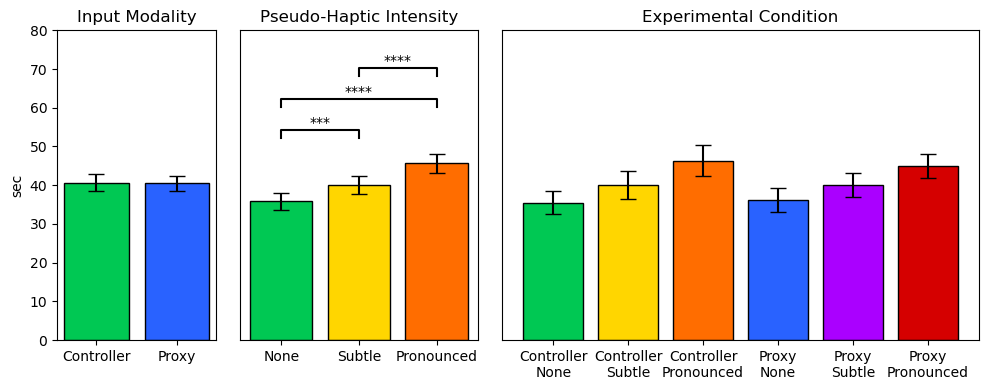

In [58]:
def single_load_time_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    loaded_time = 0
    unloaded_time = 0

    for i in range(20):
        single = df[(df["collision_or_load_count"] == i+1)]

        unloaded = single[(single["shovel_loaded_state"] == False)]
        unloaded_time += unloaded[unity_unix_key].max() - unloaded[unity_unix_key].min()

        loaded = single[(single["shovel_loaded_state"] == True)]
        loaded_time += loaded[unity_unix_key].max() - loaded[unity_unix_key].min()
    
    return [unloaded_time / 1_000, loaded_time / 1_000]

ylabel = "sec"
ylim = [0, 80]

def single_unloaded(p): return single_load_time_split(p)[0]
shovel_unloaded = report_exeriment(data, single_unloaded, shovel, "duration_shovel_unload", ylabel, ylim)

def single_loaded(p): return single_load_time_split(p)[1]
shovel_loaded = report_exeriment(data, single_loaded, shovel, "duration_shovel_load", ylabel, ylim)

------ duration_split_shovel ------


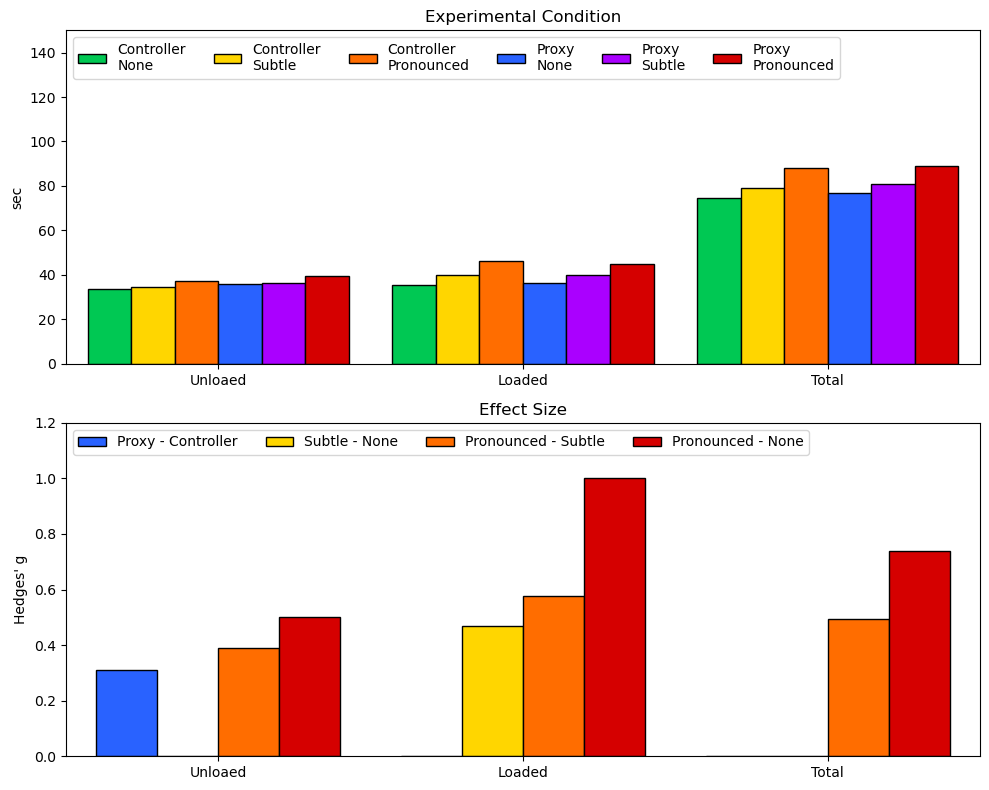

In [59]:
def get_shovel_loaded_splits(data):
    total_durations = []
    loaded_durations = []
    unloaded_durations = []

    for c in conditions:
        participant_values = list(map(lambda x: x[shovel][c], data))
        participant_totals = list(map(lambda x: task_duration(x), participant_values))
        participant_splits = list(map(lambda x: single_load_time_split(x), participant_values))

        total_durations.append(np.mean(participant_totals))

        unloaded = list(map(lambda x: x[0],  participant_splits)) #Unloaded is first in list
        unloaded_durations.append(np.mean(unloaded))
        
        loaded = list(map(lambda x: x[1],  participant_splits)) #Loaded is second in list
        loaded_durations.append(np.mean(loaded))

    return [unloaded_durations, loaded_durations, total_durations]

title = "[Shovel] Load State Splits"
ylabel= 'sec'
load_state_labels = ["Unloaed", "Loaded", "Total"]
load_state_aovs = [shovel_unloaded, shovel_loaded, shovel_duration]
load_state_splits = get_shovel_loaded_splits(data)
report_comparison(load_state_splits, load_state_aovs, load_state_labels, "duration_split_shovel", ylabel, ylim_condition=[0,150],ylim_eff=[0,1.2])